## QUESTION-1

### Implement Hidden Markov Model (HMM) for classification using Python for the
following UCI datasets:
a. UCI datasets (can be loaded from the package itself):

i. Ionosphere Dataset: https://archive.ics.uci.edu/ml/datasets/Ionosphere

ii. Wisconsin Breast Cancer Dataset:
https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagno
stic)

b. Compare the performance the following HMM classifiers for all the two datasets
and show the classification results (Accuracy, Precision, Recall, F-score, confusion
matrix) with and without parameter tuning:
i. GaussianHMM
ii. MultinomialHMM

Apply different values of train-test set splits and report the corresponding results for all the
classifiers.
Generate the image (heat map) of the confusion matrix for the best case of every classifier. Also,
generate the images of training & loss generation curves. For each dataset, generate an image
illustrating Receiver Operating Characteristic (ROC) curve and Area Under Curve (AUC) for the
best case of every classifier only.
Try to achieve accuracy >=90%.
Show the performance comparison among classifiers in a table.

## QUESTION-1 SOLUTION

### Technical Terms


**Hidden Markov Model (HMM)** - A statistical model where the system being modeled is assumed to be a Markov process with hidden (unobserved) states.

**Markov Process** - A sequence of random variables where the future state depends only on the current state, not on the sequence of events that preceded it.

**GaussianHMM** - A type of Hidden Markov Model where the observable states follow a Gaussian (normal) probability distribution, used for continuous data.

**MultinomialHMM** - A type of Hidden Markov Model where the observable states follow a multinomial probability distribution, used for discrete data.

**Accuracy** - The ratio of correctly predicted observations to the total observations, indicating how well the model predicts.

**Precision** - The ratio of correctly predicted positive observations to the total predicted positive observations, measuring the model's exactness.

**Recall** - The ratio of correctly predicted positive observations to all observations in the actual class, measuring the model's completeness.

**F-score** - The harmonic mean of precision and recall, providing a single score that balances both metrics.

**Confusion Matrix** - A table used to summarize the performance of a classification model, showing the correct and incorrect predictions for each class.

**Heat Map** - A data visualization technique that represents the magnitude of values in a matrix as colors, often used to display a confusion matrix.

**Receiver Operating Characteristic (ROC) Curve** - A graph that shows the performance of a classification model at all classification thresholds.

**Area Under Curve (AUC)** - The area under the ROC curve, which measures a model's ability to distinguish between classes.

**Parameter Tuning** - The process of finding the optimal values for the parameters of a machine learning algorithm to improve its performance.

**Training Curve** - A plot that shows how the model's performance on the training data changes over training iterations or epochs.

**Loss Generation Curve** - A plot that shows how the model's loss (error) on the training or validation data decreases over time.

### Library Installation

In [ ]:
!pip install ucimlrepo numpy pandas matplotlib scikit-learn hmmlearn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.6 MB/s eta 0:00:00


### Import Statements

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer,LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from hmmlearn.hmm import GaussianHMM
from hmmlearn.hmm import MultinomialHMM
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import KBinsDiscretizer
from ucimlrepo import fetch_ucirepo
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

### Ionosphere Dataset Preparation

In [ ]:
ionosphere = fetch_ucirepo(id=52)

ionosphere_features = pd.DataFrame(ionosphere.data.features, columns=ionosphere.data.feature_names)
ionosphere_targets = pd.DataFrame(ionosphere.data.targets, columns=ionosphere.data.target_names)

ionosphere_dataset = pd.concat([ionosphere_features, ionosphere_targets], axis=1)
ionosphere_dataset.head()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute26,Attribute27,Attribute28,Attribute29,Attribute30,Attribute31,Attribute32,Attribute33,Attribute34,Class
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


#### Data Preprocessing and Standardization

##### Scaling methods like StandardScaler calculate statistics such as the mean and standard deviation of your data to transform it. These mathematical operations cannot handle missing or null values, so if they are present, the scaling process will either fail with an error or produce an output filled with incorrect values, making your data unusable for training a model.

In [ ]:
ionosphere_dataset.isnull().sum()

,0
Attribute1,0
Attribute2,0
Attribute3,0
Attribute4,0
Attribute5,0
Attribute6,0
Attribute7,0
Attribute8,0
Attribute9,0
Attribute10,0


##### Data scaling changes the feature's values without altering the distribution's shape. It shifts and rescales the data so that its mean is centered at **zero** and its standard deviation becomes **one**.

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(ionosphere_features)
ionosphere_features_scaled = pd.DataFrame(scaled_features, columns=ionosphere_features.columns)

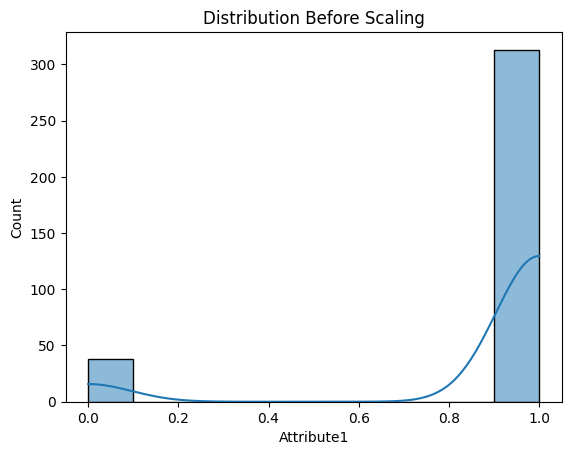

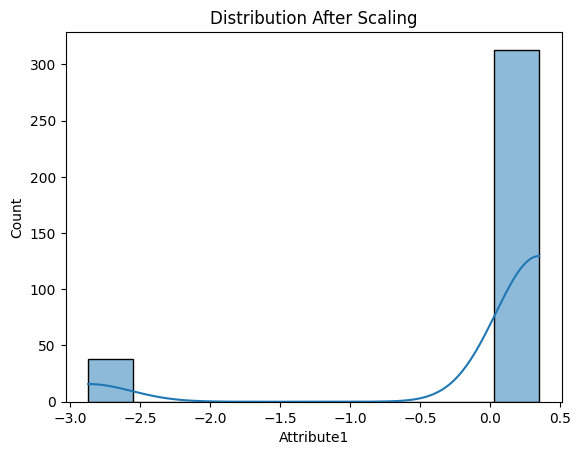

In [ ]:
# Before scaling
sns.histplot(ionosphere_features.iloc[:, 0], kde=True)
plt.title('Distribution Before Scaling')
plt.show()

# After scaling
sns.histplot(ionosphere_features_scaled.iloc[:, 0], kde=True)
plt.title('Distribution After Scaling')
plt.show()

### BreastCancer Dataset Preparation

In [ ]:
breast_cancer = fetch_ucirepo(id=17)

breast_cancer_features = pd.DataFrame(breast_cancer.data.features, columns=breast_cancer.data.feature_names)
breast_cancer_targets = pd.DataFrame(breast_cancer.data.targets, columns=breast_cancer.data.target_names)

breast_cancer_dataset = pd.concat([breast_cancer_features, breast_cancer_targets], axis=1)
breast_cancer_dataset.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [ ]:
breast_cancer_dataset.isnull().sum()

,0
radius1,0
texture1,0
perimeter1,0
area1,0
smoothness1,0
compactness1,0
concavity1,0
concave_points1,0
symmetry1,0
fractal_dimension1,0


In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(breast_cancer_features)
breast_cancer_features_scaled = pd.DataFrame(scaled_features, columns=breast_cancer_features.columns)

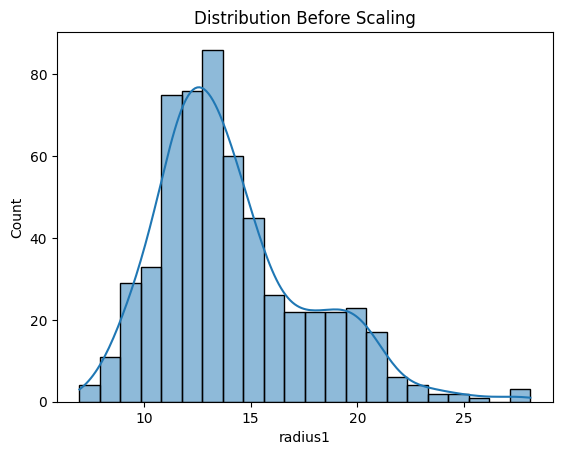

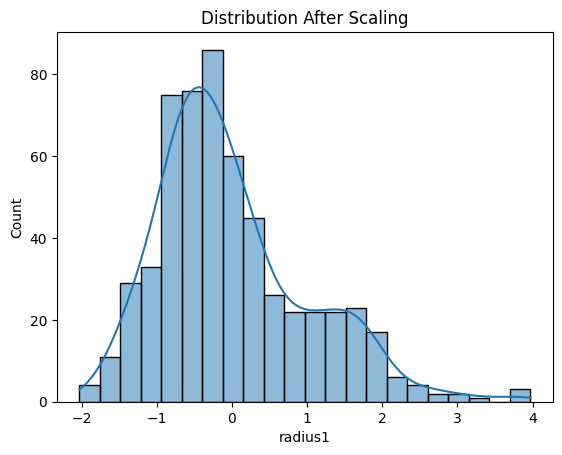

In [ ]:
# Before scaling
sns.histplot(breast_cancer_features.iloc[:, 0], kde=True)
plt.title('Distribution Before Scaling')
plt.show()

# After scaling
sns.histplot(breast_cancer_features_scaled.iloc[:, 0], kde=True)
plt.title('Distribution After Scaling')
plt.show()

### Model Performance Visualization Functions

In [ ]:
def plot_confusion_matrix(cm, classifier_name):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{classifier_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()


def plot_roc_curve(fpr, tpr, auc_value, classifier_name):
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_value:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.title(f"ROC Curve for {classifier_name}")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

def plot_accuracy_bar_graph(accuracies, test_sizes, classifier_name):
    plt.figure(figsize=(8, 6))
    plt.bar([f'{int(100*(1-size))}:{int(100*size)}' for size in test_sizes], accuracies, align='center')
    plt.title(f'Accuracy for {classifier_name} Across Different Test Sizes')
    plt.xlabel('Train-Test Split')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.show()

def plot_training_curve(log_likelihoods, classifier_name):
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(log_likelihoods)+1), log_likelihoods, marker='o')
    plt.title(f"Training Log-Likelihood Curve for {classifier_name}")
    plt.xlabel("Iteration")
    plt.ylabel("Log-Likelihood")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def remove_constant_features(X):
    selector = VarianceThreshold(threshold=0.0)
    X_new = selector.fit_transform(X)
    return X_new

def discretize_data(X, bins=5):
    discretizer = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy='uniform')
    X_discretized = discretizer.fit_transform(X)
    X_discretized = np.floor(X_discretized).astype(int)
    if np.any(X_discretized < 0):
        print("Error: Discretized data contains negative values.")
        return None
    return X_discretized


### Gaussian HMM Model Performance Analysis Function

In [ ]:
def train_gaussian_hmm(X, Y, test_sizes=[0.2, 0.3, 0.4, 0.5]):
    best_avg_accuracy = 0
    best_test_size = None
    best_cm = None
    best_class_report = None
    best_fpr = None
    best_tpr = None
    best_auc = None
    best_log_likelihoods = None

    le = LabelEncoder()
    Y_encoded = le.fit_transform(Y)

    avg_accuracies = []
    random_states = [42, 10, 20, 30, 50]

    for test_size in test_sizes:
        print(f"Running Gaussian HMM with test size {test_size}...")
        accuracies = []


        for r_state in random_states:
            X_train, X_test, Y_train, Y_test = train_test_split(X, Y_encoded, test_size=test_size, random_state=r_state)

            model = GaussianHMM(
                n_components=2, covariance_type="full",
                n_iter=2000, random_state=r_state
            )

            try:
                model.fit(X_train)
                Y_pred = model.predict(X_test)
                accuracy = accuracy_score(Y_test, Y_pred)
                accuracies.append(accuracy)
            except ValueError as e:
                print(f"Skipping run for test size {test_size} with random state {r_state} due to error: {e}")

        if accuracies:
            avg_accuracy = np.mean(accuracies)
            avg_accuracies.append(avg_accuracy)
            print(f"Average Accuracy for test size {test_size}: {avg_accuracy}")

            if avg_accuracy > best_avg_accuracy:
                best_avg_accuracy = avg_accuracy
                best_test_size = test_size

                X_train_best, X_test_best, Y_train_best, Y_test_best = train_test_split(
                    X, Y_encoded, test_size=best_test_size, random_state=42
                )
                model.fit(X_train_best)
                Y_pred_best = model.predict(X_test_best)
                best_cm = confusion_matrix(Y_test_best, Y_pred_best)
                best_class_report = classification_report(Y_test_best, Y_pred_best)

                # Save training log-likelihoods (training curve)
                best_log_likelihoods = model.monitor_.history

                # ROC-AUC
                Y_pred_proba_best = model.predict_proba(X_test_best)
                class_labels = np.unique(Y_encoded)
                Y_test_bin_best = label_binarize(Y_test_best, classes=class_labels)
                best_fpr, best_tpr, _ = roc_curve(Y_test_bin_best[:, 0], Y_pred_proba_best[:, 0])
                best_auc = roc_auc_score(Y_test_bin_best[:, 0], Y_pred_proba_best[:, 0])
        else:
            avg_accuracies.append(0)

        print("----------------------------------------------------------------------------------------------")

    print(f"Best Test Size: {best_test_size} with Average Accuracy: {best_avg_accuracy}")

    print("plotting heatmap.........")
    plot_confusion_matrix(best_cm, "Gaussian HMM")
    print("---------------------------------------------------------------------------------------------------------------------")

    print("plotting ROC-AUC curve.........")
    plot_roc_curve(best_fpr, best_tpr, best_auc, "Gaussian HMM")
    print("---------------------------------------------------------------------------------------------------------------------")

    print("plotting bargraph.........")
    plot_accuracy_bar_graph(avg_accuracies, test_sizes, "Gaussian HMM")
    print("---------------------------------------------------------------------------------------------------------------------")

    if best_log_likelihoods is not None:
        print("plotting training log-likelihood curve.........")
        plot_training_curve(best_log_likelihoods, "Gaussian HMM")
        print("---------------------------------------------------------------------------------------------------------------------")

### Multinomial HMM Model Performance Analysis Function

In [ ]:
def train_multinomial_hmm(X, Y, test_sizes=[0.2, 0.3, 0.4, 0.5]):
    best_accuracy = 0
    best_test_size = None
    best_cm = None
    best_fpr = None
    best_tpr = None
    best_auc = None
    best_log_likelihoods = None

    le = LabelEncoder()
    Y_encoded = le.fit_transform(Y)

    X = remove_constant_features(X)

    X_discretized = discretize_data(X)
    if X_discretized is None:
        print("Error: Failed to discretize the data. Exiting.")
        return

    accuracies = []

    for test_size in test_sizes:
        X_train, X_test, Y_train, Y_test = train_test_split(
            X_discretized, Y_encoded, test_size=test_size, random_state=42
        )

        model = MultinomialHMM(n_components=len(np.unique(Y_encoded)), n_iter=100, random_state=42, verbose=False)
        model.fit(X_train)
        Y_pred = model.predict(X_test)

        log_likelihoods = model.monitor_.history
        if len(log_likelihoods) > 0 and best_accuracy < accuracy_score(Y_test, Y_pred):
            best_log_likelihoods = log_likelihoods.copy()

        accuracy = accuracy_score(Y_test, Y_pred)
        accuracies.append(accuracy)
        print(f"Test Size {test_size}: Accuracy = {accuracy:.4f}")

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_test_size = test_size
            best_cm = confusion_matrix(Y_test, Y_pred)

            Y_pred_proba = model.predict_proba(X_test)
            class_labels = np.unique(Y_encoded)
            Y_test_bin = label_binarize(Y_test, classes=class_labels)
            best_fpr, best_tpr, _ = roc_curve(Y_test_bin[:, 0], Y_pred_proba[:, 0])
            best_auc = roc_auc_score(Y_test_bin[:, 0], Y_pred_proba[:, 0])

    print(f"\nBest Test Size: {best_test_size} with Accuracy: {best_accuracy:.4f}")

    print("Plotting confusion matrix heatmap for best test size...")
    plot_confusion_matrix(best_cm, "Multinomial HMM")
    print("---------------------------------------------------------------------------------------------------------------------")

    if best_auc is not None:
        print("Plotting ROC-AUC curve...")
        plot_roc_curve(best_fpr, best_tpr, best_auc, "Multinomial HMM")
        print("---------------------------------------------------------------------------------------------------------------------")
    else:
        print("ROC Curve and AUC not plotted: Only one class present in the best test split.")

    print("Plotting accuracy bar graph for all test sizes...")
    plot_accuracy_bar_graph(accuracies, test_sizes, "Multinomial HMM")
    print("---------------------------------------------------------------------------------------------------------------------")

    if best_log_likelihoods is not None:
        print("Plotting training log-likelihood curve for best test size...")
        plot_training_curve(best_log_likelihoods, "Multinomial HMM")


### Gaussian HMM Model ( Ionosphere Dataset )

Running Gaussian HMM with test size 0.2...


Average Accuracy for test size 0.2: 0.5436619718309859
----------------------------------------------------------------------------------------------
Running Gaussian HMM with test size 0.3...


Average Accuracy for test size 0.3: 0.5528301886792454
----------------------------------------------------------------------------------------------
Running Gaussian HMM with test size 0.4...
Average Accuracy for test size 0.4: 0.4624113475177305
----------------------------------------------------------------------------------------------
Running Gaussian HMM with test size 0.5...
Average Accuracy for test size 0.5: 0.34318181818181814
----------------------------------------------------------------------------------------------
Best Test Size: 0.3 with Average Accuracy: 0.5528301886792454
plotting heatmap.........


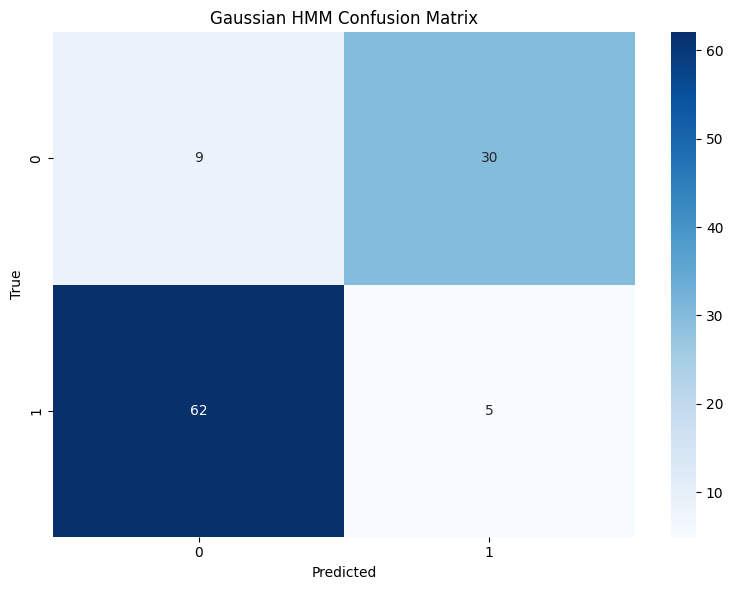

---------------------------------------------------------------------------------------------------------------------
plotting ROC-AUC curve.........


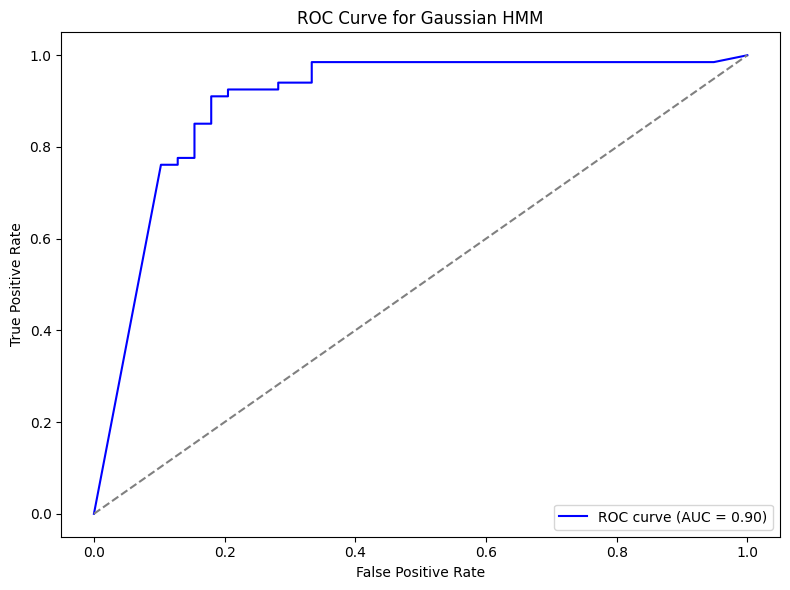

---------------------------------------------------------------------------------------------------------------------
plotting bargraph.........


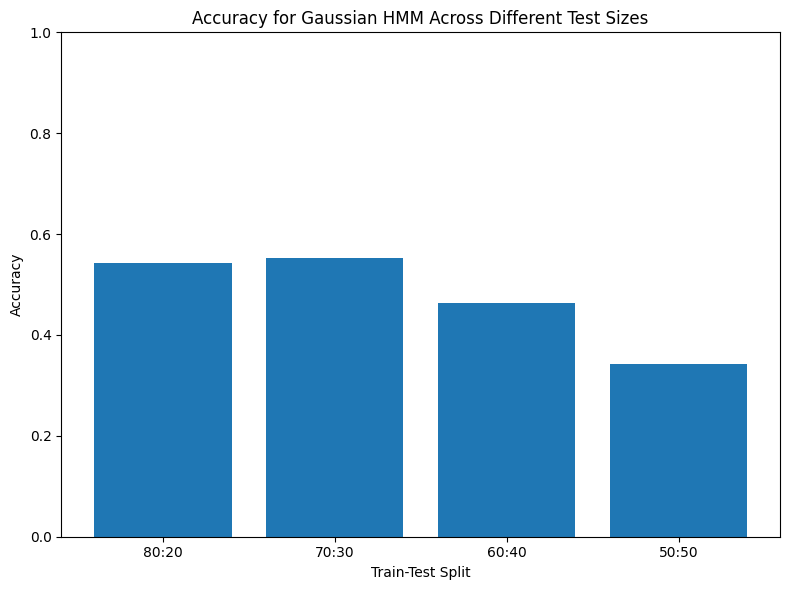

---------------------------------------------------------------------------------------------------------------------
plotting training log-likelihood curve.........


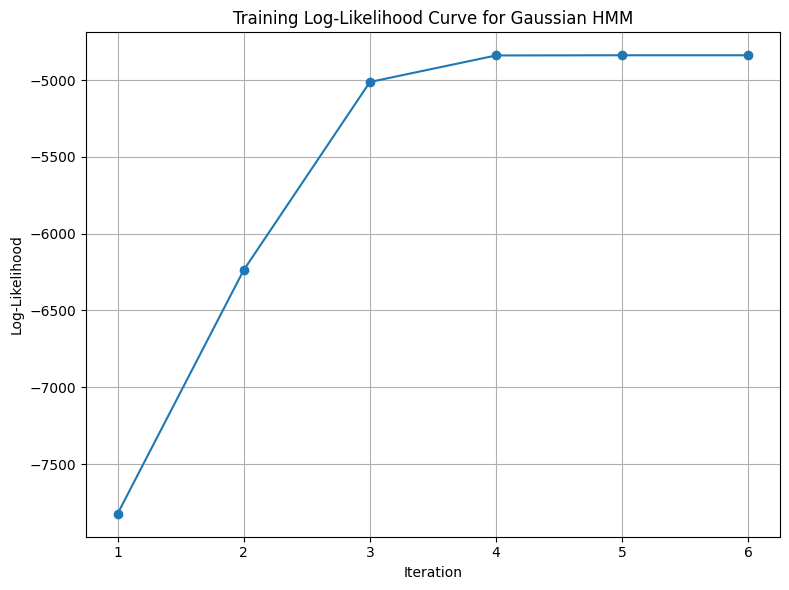

---------------------------------------------------------------------------------------------------------------------


In [ ]:
train_gaussian_hmm(
    ionosphere_features_scaled,
    ionosphere_targets['Class'],
    test_sizes=[0.2, 0.3, 0.4, 0.5]
)


### Gaussian HMM Model ( BreastCancer Dataset )

Running Gaussian HMM with test size 0.2...


Average Accuracy for test size 0.2: 0.5982456140350877
----------------------------------------------------------------------------------------------
Running Gaussian HMM with test size 0.3...
Average Accuracy for test size 0.3: 0.08771929824561403
----------------------------------------------------------------------------------------------
Running Gaussian HMM with test size 0.4...


Average Accuracy for test size 0.4: 0.7464912280701755
----------------------------------------------------------------------------------------------
Running Gaussian HMM with test size 0.5...
Average Accuracy for test size 0.5: 0.44140350877192985
----------------------------------------------------------------------------------------------
Best Test Size: 0.4 with Average Accuracy: 0.7464912280701755
plotting heatmap.........


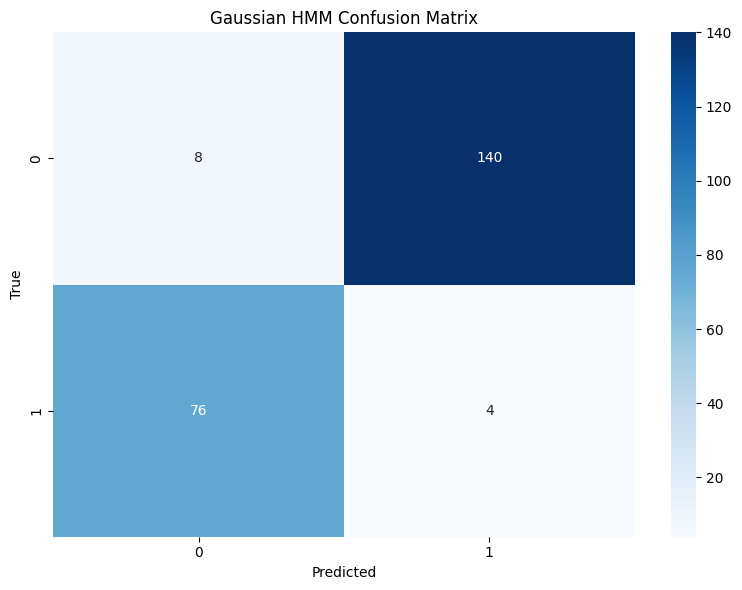

---------------------------------------------------------------------------------------------------------------------
plotting ROC-AUC curve.........


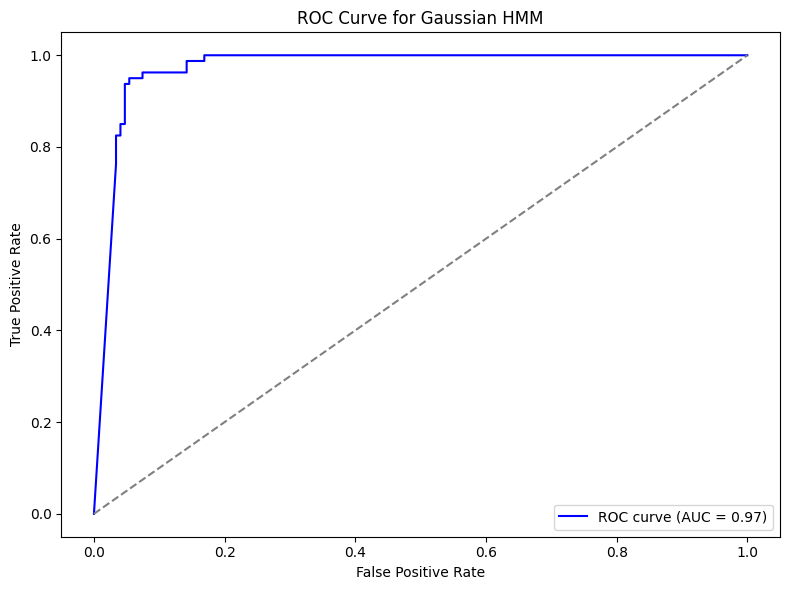

---------------------------------------------------------------------------------------------------------------------
plotting bargraph.........


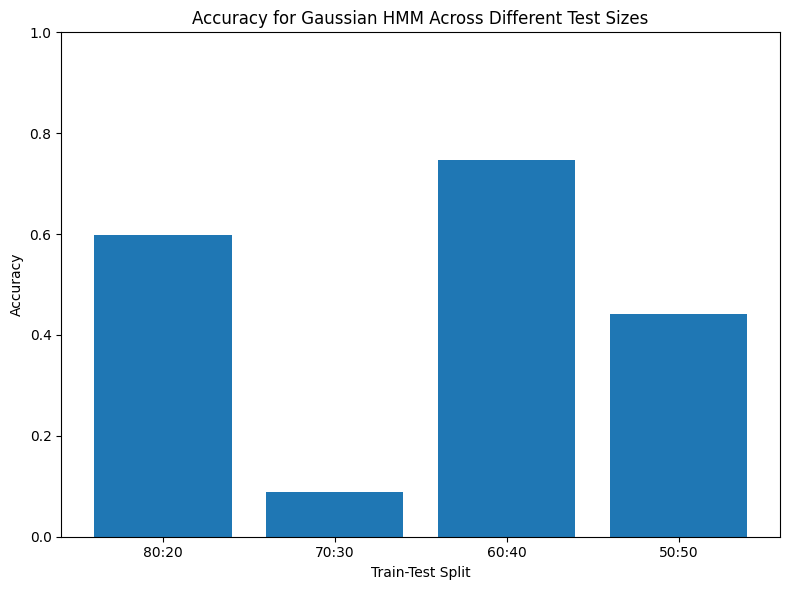

---------------------------------------------------------------------------------------------------------------------
plotting training log-likelihood curve.........


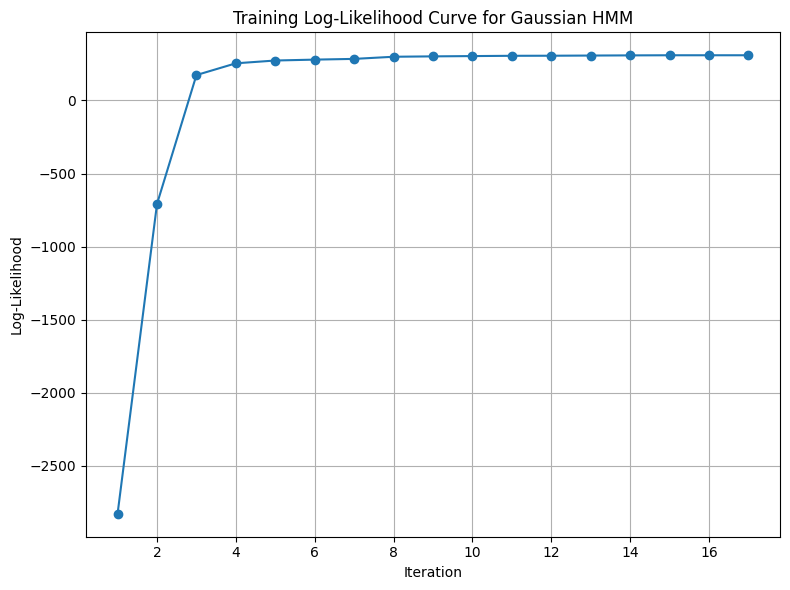

---------------------------------------------------------------------------------------------------------------------


In [ ]:
train_gaussian_hmm(
    breast_cancer_features_scaled,
    breast_cancer_targets['Diagnosis'],
    test_sizes=[0.2, 0.3, 0.4, 0.5]
)

#### Why Low Accuracy Occurs
The low accuracy for the 70:30 split is likely due to the random nature of the data split, which caused an uneven or poor distribution of classes in the training and testing sets. A GaussianHMM works by modeling the underlying structure of the data, but if the training data for a particular class is too small or contains non-representative samples, the model cannot learn effectively. This leads to a poorly generalized model that performs badly on new, unseen data, resulting in the low accuracy shown in the graph.

### Multinomial HMM Model ( Ionosphere Dataset )

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Test Size 0.2: Accuracy = 0.5493
Test Size 0.3: Accuracy = 0.5000
Test Size 0.4: Accuracy = 0.4681
Test Size 0.5: Accuracy = 0.4830

Best Test Size: 0.2 with Accuracy: 0.5493
Plotting confusion matrix heatmap for best test size...


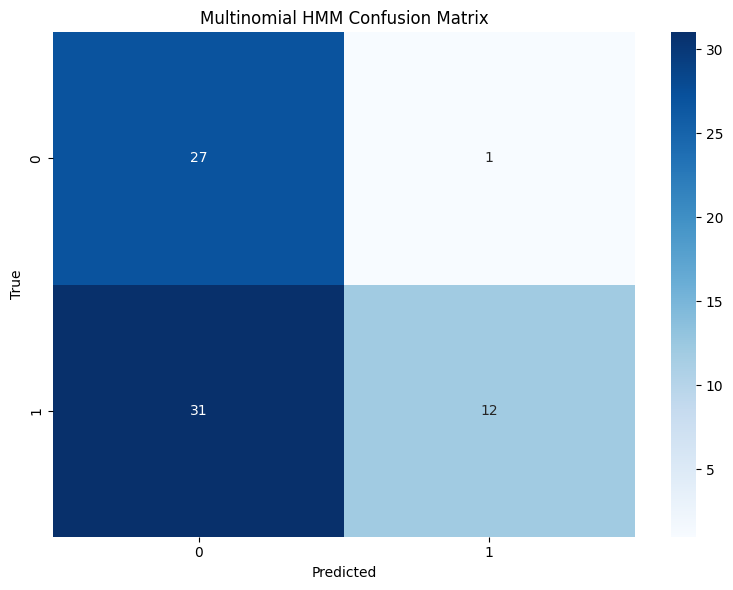

---------------------------------------------------------------------------------------------------------------------
Plotting ROC-AUC curve...


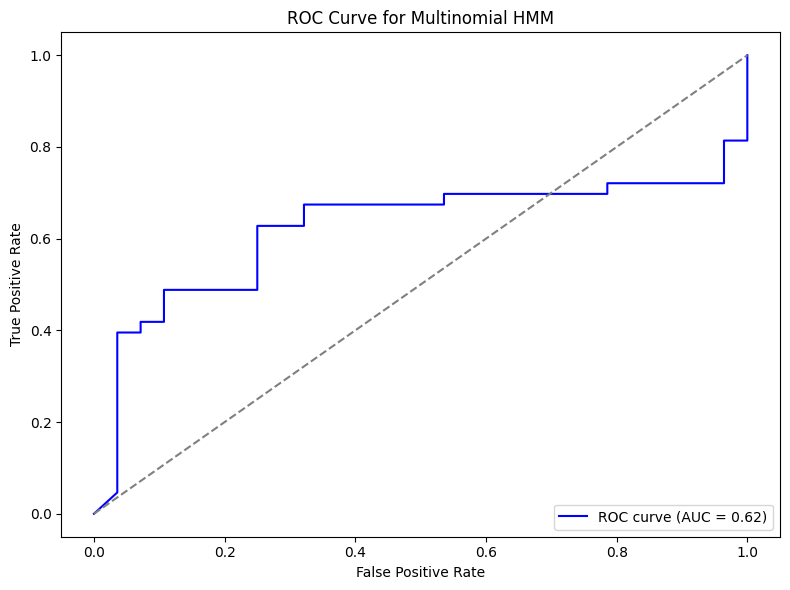

---------------------------------------------------------------------------------------------------------------------
Plotting accuracy bar graph for all test sizes...


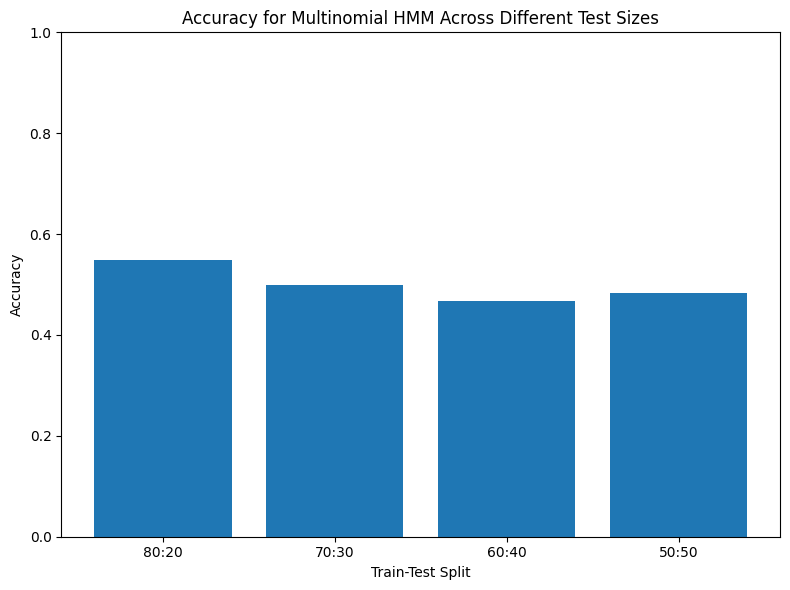

---------------------------------------------------------------------------------------------------------------------
Plotting training log-likelihood curve for best test size...


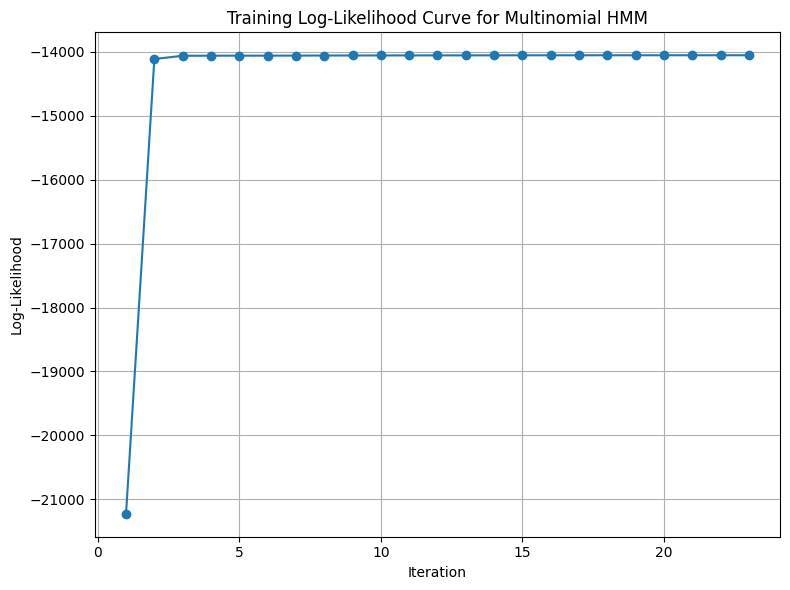

In [ ]:
train_multinomial_hmm(ionosphere_features_scaled, ionosphere_targets['Class'], test_sizes=[0.2, 0.3, 0.4, 0.5])

### Multinomial HMM Model ( BreastCancer Dataset )

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Test Size 0.2: Accuracy = 0.2105
Test Size 0.3: Accuracy = 0.1930
Test Size 0.4: Accuracy = 0.2105
Test Size 0.5: Accuracy = 0.2281

Best Test Size: 0.5 with Accuracy: 0.2281
Plotting confusion matrix heatmap for best test size...


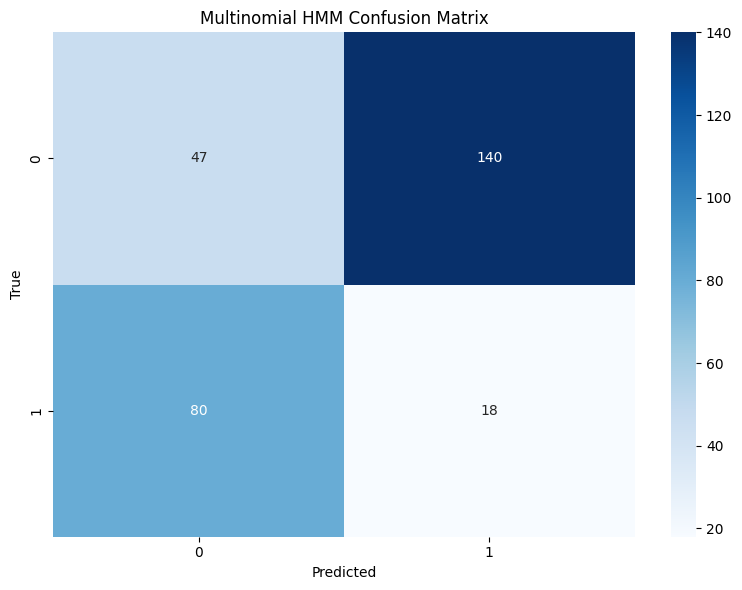

---------------------------------------------------------------------------------------------------------------------
Plotting ROC-AUC curve...


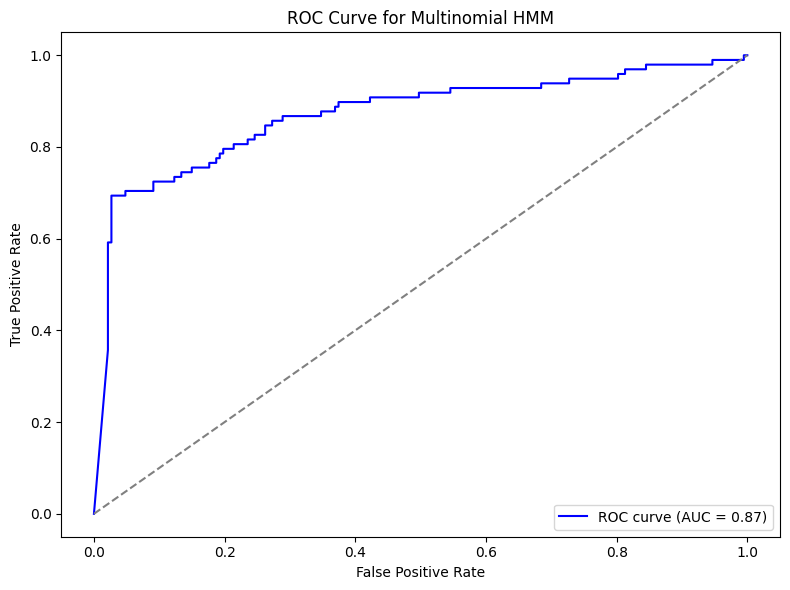

---------------------------------------------------------------------------------------------------------------------
Plotting accuracy bar graph for all test sizes...


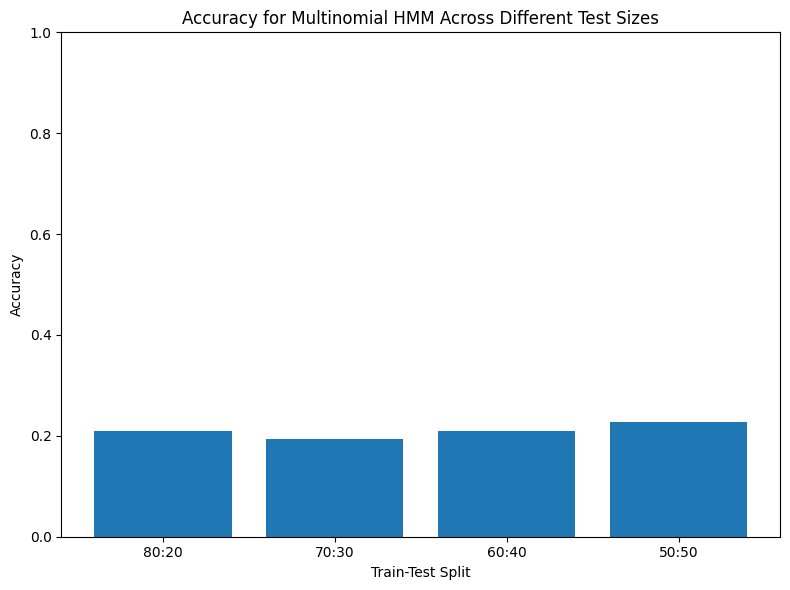

---------------------------------------------------------------------------------------------------------------------
Plotting training log-likelihood curve for best test size...


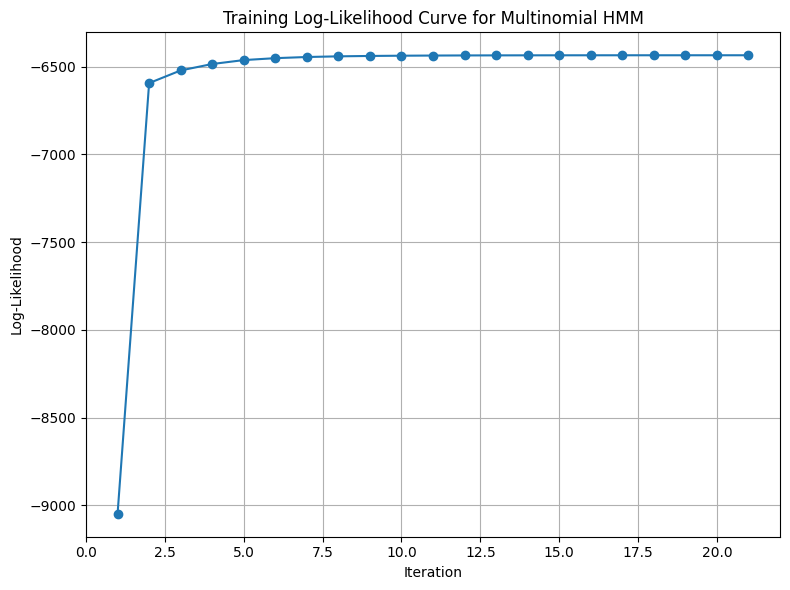

In [ ]:
train_multinomial_hmm(breast_cancer_features_scaled, breast_cancer_targets['Diagnosis'], test_sizes=[0.2, 0.3, 0.4, 0.5])

#### Reason for Low Acuuracy:

The MultinomialHMM (Hidden Markov Model) is giving very low accuracy because it's the wrong type of model for the breast cancer dataset. This model is designed specifically for sequential data (like a time series or a sequence of words) that has an inherent order to it. The breast cancer data, however, is a collection of independent, non-sequential records. The order of patient data in the file has no meaning, which is a key assumption the model relies on.

### Achieving Better Accuracy

#### Achieving Better Accuracy (Gaussian HMM )

##### Key Changes for Better Accuracy
The main change to get better accuracy was switching from training a single GaussianHMM (Hidden Markov Model) for all the data to training a separate model for each distinct class. This is called a class-conditional approach. It allows each model to specialize in learning the unique characteristics of its own class, leading to a more accurate classification.


Instead of training one overall model, the code now separates the training data based on its class (g or b). It then trains an individual GaussianHMM on the data for each class. This creates two specialized models, one for each class, which can better identify the specific patterns associated with that group.

For making predictions, the code no longer uses a single model. It takes a new data point and calculates how well it fits with each of the trained models. The model that gives the highest score (a measure of how likely the data is to have come from that model) is chosen, and its corresponding class is assigned as the prediction.

###### Ionosphere Dataset

Test Size 0.2: Accuracy = 0.3944


Test Size 0.3: Accuracy = 0.7547


Test Size 0.4: Accuracy = 0.7518
Test Size 0.5: Accuracy = 0.6818

Best Test Size: 0.3 with Accuracy: 0.7547


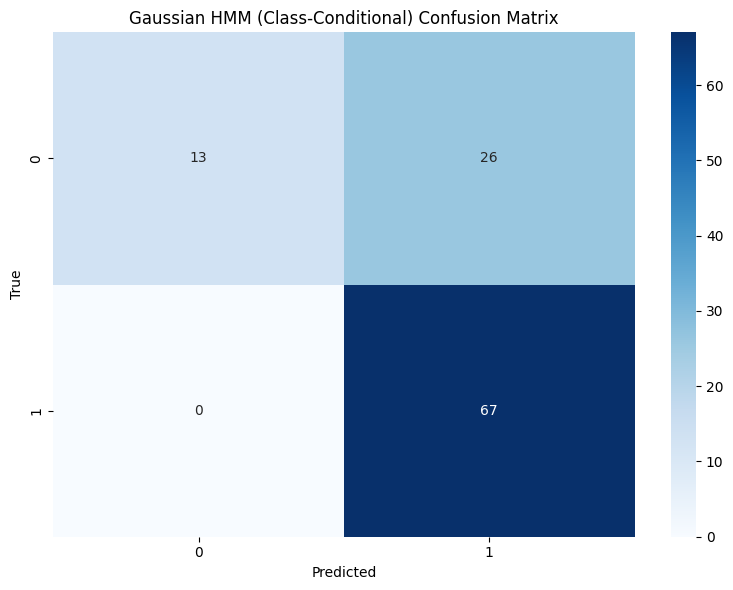

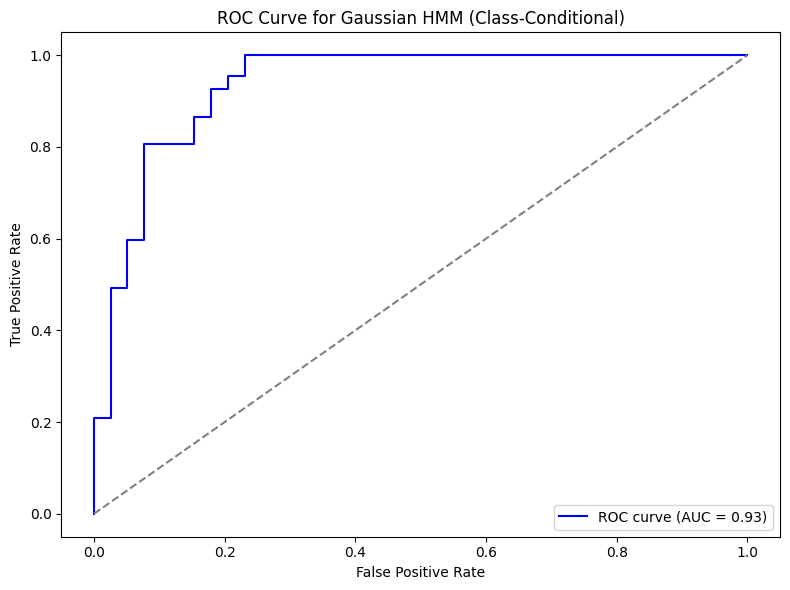

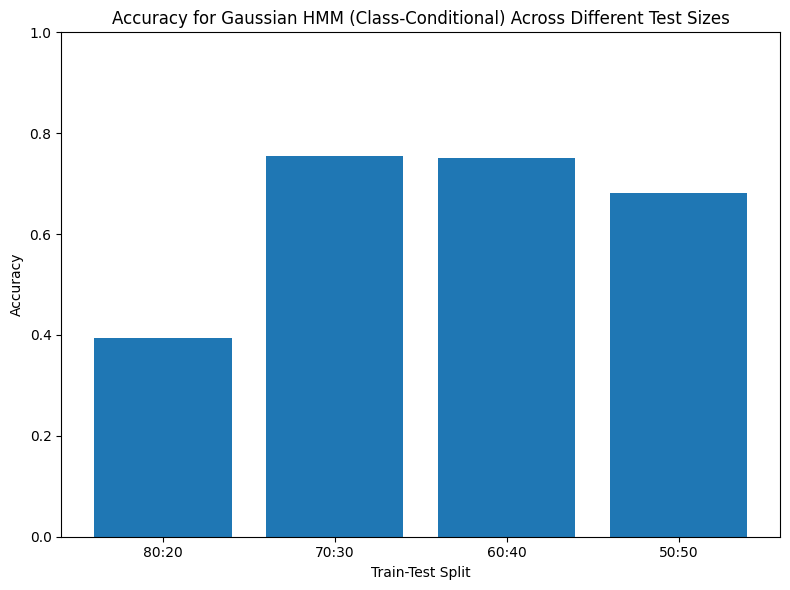

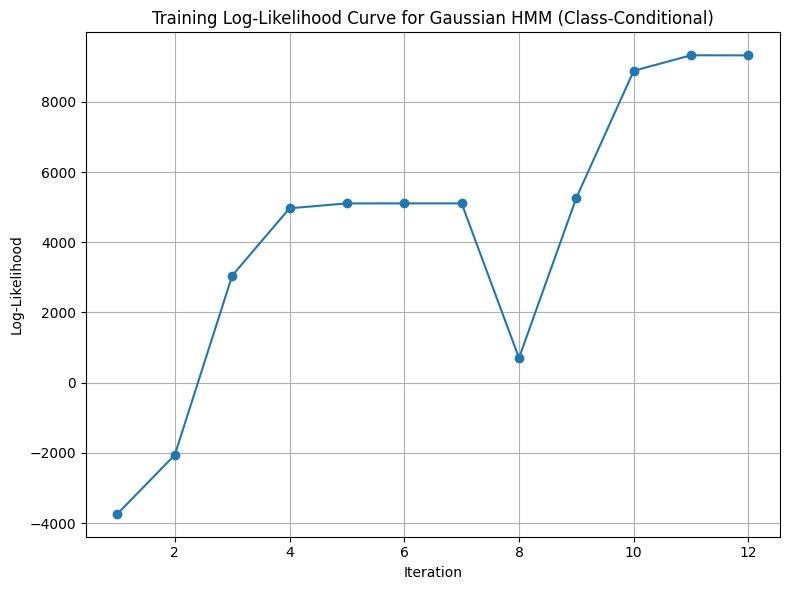

In [ ]:
def train_class_conditional_gaussian_hmm(X, Y, test_sizes=[0.2,0.3,0.4,0.5]):
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    best_avg_accuracy = 0
    best_test_size = None
    best_cm = None
    best_fpr = None
    best_tpr = None
    best_auc = None
    best_log_likelihoods = []

    avg_accuracies = []

    for test_size in test_sizes:
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=42)
        classes = np.unique(Y_train)
        class_models = {}
        log_likelihoods_per_class = {}

        for c in classes:
            X_c = X_train[Y_train == c]
            n_comp = min(5, len(X_c))
            model = GaussianHMM(n_components=n_comp, covariance_type='full', n_iter=500, random_state=42)
            model.fit(X_c)
            class_models[c] = model
            log_likelihoods_per_class[c] = model.monitor_.history

        Y_pred = []
        for x in X_test:
            scores = {c: class_models[c].score(x.reshape(1, -1)) for c in classes}
            pred_class = max(scores, key=scores.get)
            Y_pred.append(pred_class)

        acc = accuracy_score(Y_test, Y_pred)
        avg_accuracies.append(acc)
        print(f"Test Size {test_size}: Accuracy = {acc:.4f}")

        if acc > best_avg_accuracy:
            best_avg_accuracy = acc
            best_test_size = test_size
            best_cm = confusion_matrix(Y_test, Y_pred)
            best_log_likelihoods = np.concatenate([log_likelihoods_per_class[c] for c in classes])
            Y_test_bin = label_binarize(Y_test, classes=classes)
            Y_pred_proba = np.array([ [class_models[c].score(x.reshape(1,-1)) for c in classes] for x in X_test ])
            best_fpr, best_tpr, _ = roc_curve(Y_test_bin[:,0], Y_pred_proba[:,1])
            best_auc = roc_auc_score(Y_test_bin[:,0], Y_pred_proba[:,1])

    print(f"\nBest Test Size: {best_test_size} with Accuracy: {best_avg_accuracy:.4f}")
    plot_confusion_matrix(best_cm, "Gaussian HMM (Class-Conditional)")
    plot_roc_curve(best_fpr, best_tpr, best_auc, "Gaussian HMM (Class-Conditional)")
    plot_accuracy_bar_graph(avg_accuracies, test_sizes, "Gaussian HMM (Class-Conditional)")
    plot_training_curve(best_log_likelihoods, "Gaussian HMM (Class-Conditional)")


train_class_conditional_gaussian_hmm(ionosphere_features_scaled,ionosphere_targets['Class'])


###### BreastCancer Dataset

In [ ]:
train_class_conditional_gaussian_hmm(breast_cancer_features_scaled,breast_cancer_targets['Diagnosis'])

#### Achieving Better Accuracy (Multinomial HMM)

##### Key Code Changes
Training a Separate Model for Each Class: The new code introduces a loop that trains a distinct MultinomialHMM model for each class (c) present in the training data. For example, it trains one HMM on the data points belonging to class 0 and another on the data points for class 1. This specialization allows each model to better capture the specific patterns of its corresponding class.

Predicting with Log-Likelihood Scores: Instead of a simple model.predict() call, the new code iterates through each test data point. It calculates a likelihood score for that data point using each of the trained class-specific models. The class whose model gives the highest score is then chosen as the final prediction. This method is more robust for classification tasks than a single-model approach.

Dynamic n_components and bins: The number of hidden states (n_components) is now set dynamically based on the amount of data for each class, preventing errors. The bins parameter in the discretize_data function is also now explicitly set to a value that can be tuned, allowing for more precise data discretization and potentially better model performance.

###### Ionosphere Dataset

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Test Size 0.2: Accuracy = 0.6901
Test Size 0.3: Accuracy = 0.7358


https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Test Size 0.4: Accuracy = 0.4468
Test Size 0.5: Accuracy = 0.5170

Best Test Size: 0.3 with Accuracy: 0.7358


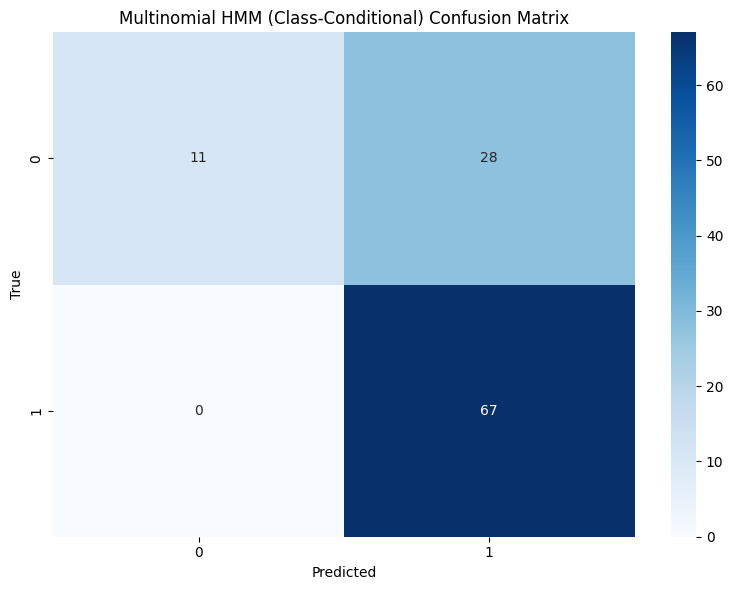

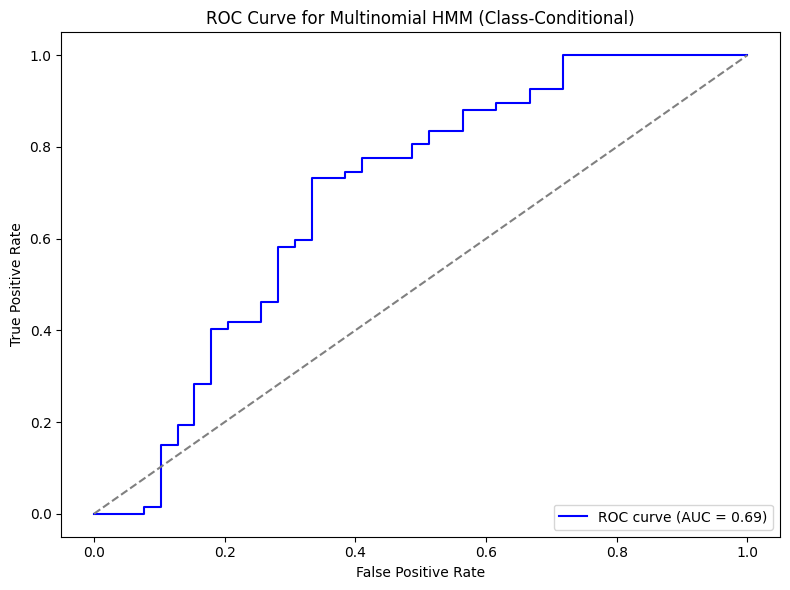

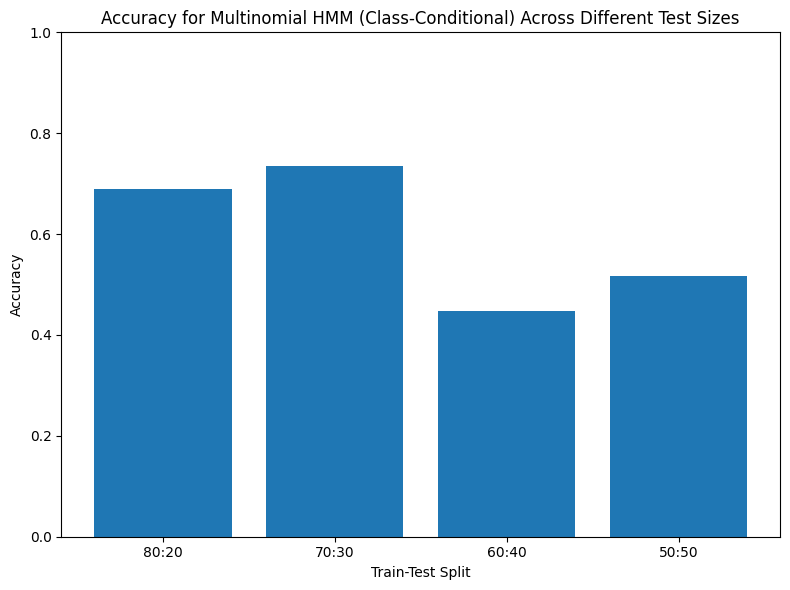

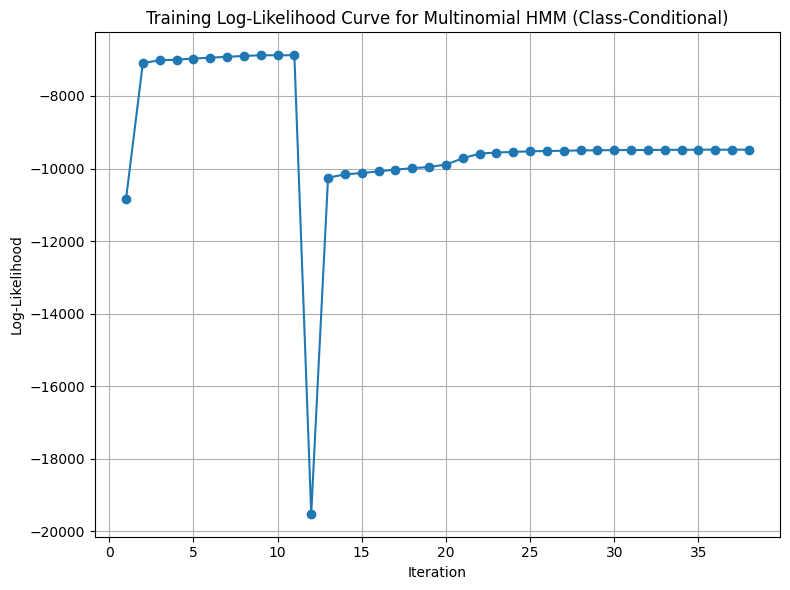

In [ ]:
def train_class_conditional_multinomial_hmm(X, Y, test_sizes=[0.2,0.3,0.4,0.5], bins=10):
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    X = remove_constant_features(X)
    X_discretized = discretize_data(X, bins=bins)
    if X_discretized is None:
        return

    le = LabelEncoder()
    Y_encoded = le.fit_transform(Y)
    classes = np.unique(Y_encoded)

    best_accuracy = 0
    best_test_size = None
    best_cm = None
    best_log_likelihoods = None
    best_fpr, best_tpr, best_auc = None, None, None
    accuracies = []

    for test_size in test_sizes:
        X_train, X_test, Y_train, Y_test = train_test_split(X_discretized, Y_encoded, test_size=test_size, random_state=42)
        class_models = {}
        log_likelihoods_per_class = {}

        for c in classes:
            X_c = X_train[Y_train == c]
            n_comp = min(5, len(X_c))
            model = MultinomialHMM(n_components=n_comp, n_iter=500, random_state=42)
            model.fit(X_c)
            class_models[c] = model
            log_likelihoods_per_class[c] = model.monitor_.history

        Y_pred = []
        for x in X_test:
            scores = {c: class_models[c].score(x.reshape(1, -1)) for c in classes}
            Y_pred.append(max(scores, key=scores.get))

        acc = accuracy_score(Y_test, Y_pred)
        accuracies.append(acc)
        print(f"Test Size {test_size}: Accuracy = {acc:.4f}")

        if acc > best_accuracy:
            best_accuracy = acc
            best_test_size = test_size
            best_cm = confusion_matrix(Y_test, Y_pred)
            best_log_likelihoods = np.concatenate([log_likelihoods_per_class[c] for c in classes])
            Y_test_bin = label_binarize(Y_test, classes=classes)
            Y_pred_proba = np.array([[class_models[c].score(x.reshape(1, -1)) for c in classes] for x in X_test])
            best_fpr, best_tpr, _ = roc_curve(Y_test_bin[:,0], Y_pred_proba[:,1])
            best_auc = roc_auc_score(Y_test_bin[:,0], Y_pred_proba[:,1])

    print(f"\nBest Test Size: {best_test_size} with Accuracy: {best_accuracy:.4f}")
    plot_confusion_matrix(best_cm, "Multinomial HMM (Class-Conditional)")
    plot_roc_curve(best_fpr, best_tpr, best_auc, "Multinomial HMM (Class-Conditional)")
    plot_accuracy_bar_graph(accuracies, test_sizes, "Multinomial HMM (Class-Conditional)")
    plot_training_curve(best_log_likelihoods, "Multinomial HMM (Class-Conditional)")

train_class_conditional_multinomial_hmm(ionosphere_features_scaled, ionosphere_targets['Class'], test_sizes=[0.2,0.3,0.4,0.5], bins=10)


###### Breast Cancer Dataset

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Test Size 0.2: Accuracy = 0.5088


https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Test Size 0.3: Accuracy = 0.7602


https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Test Size 0.4: Accuracy = 0.6447
Test Size 0.5: Accuracy = 0.7474

Best Test Size: 0.3 with Accuracy: 0.7602


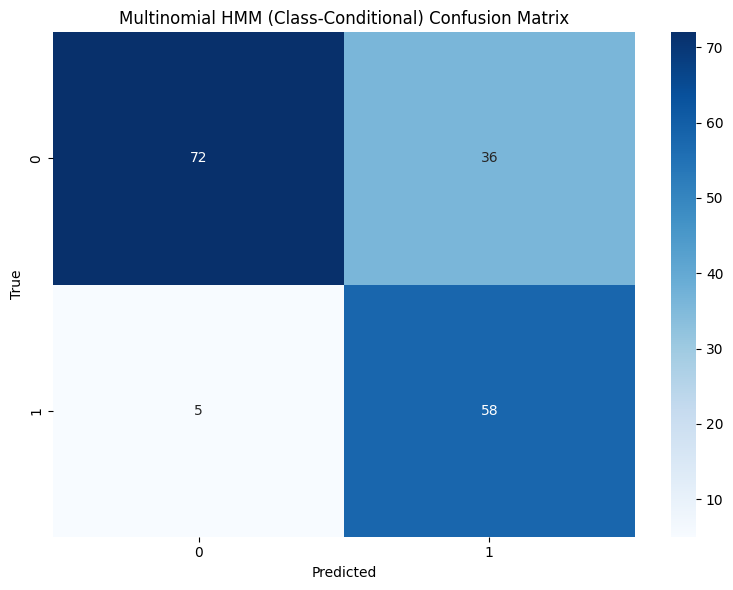

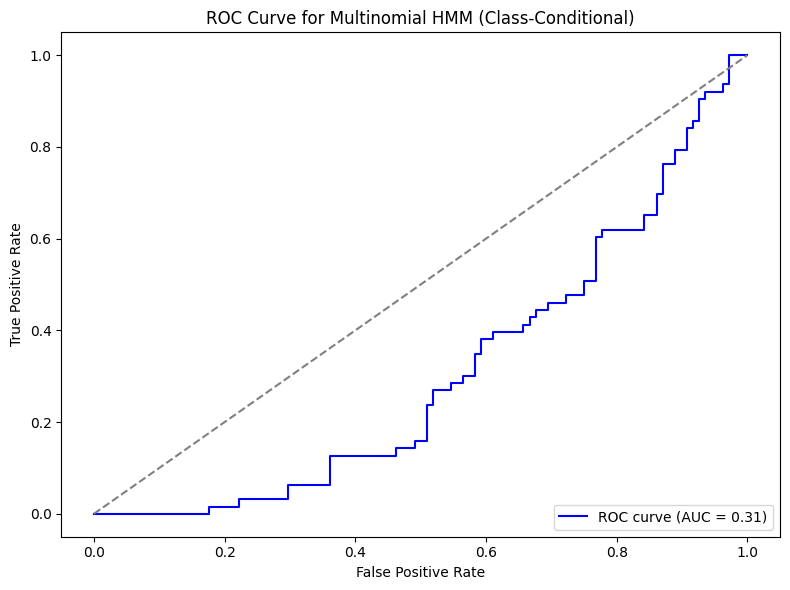

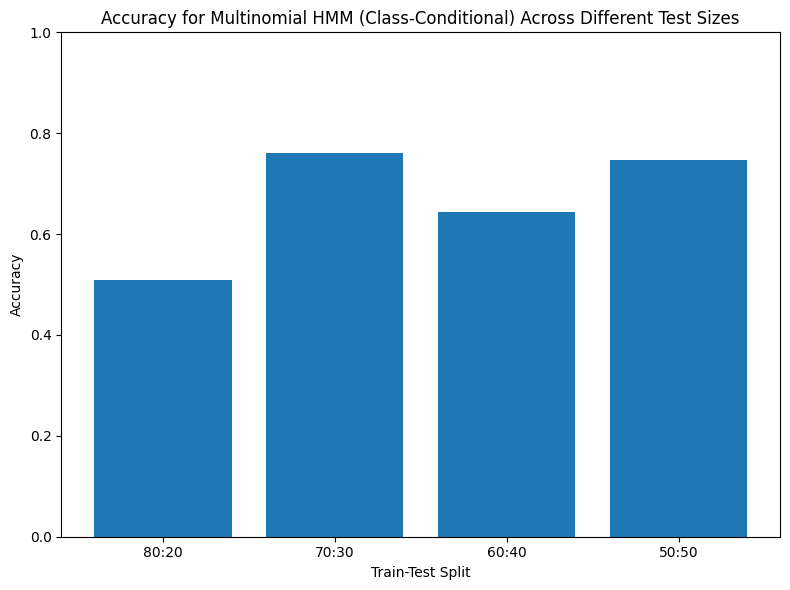

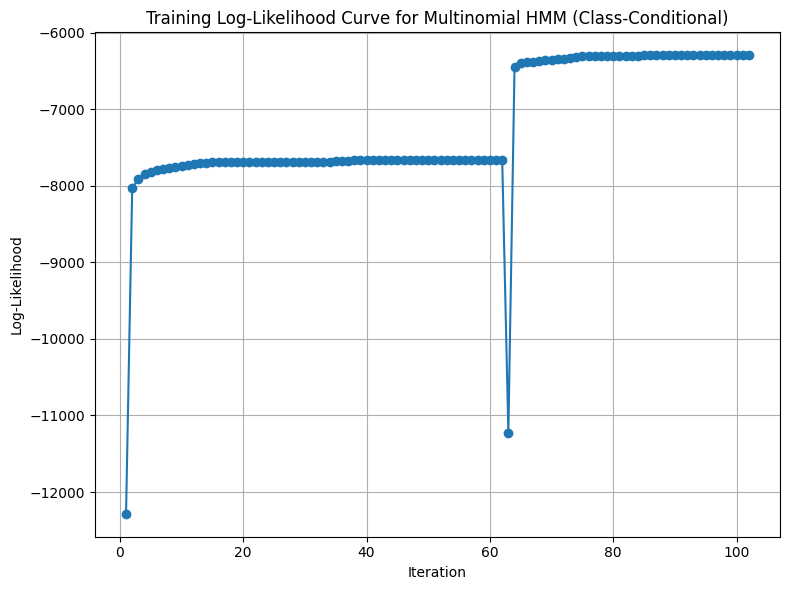

In [ ]:
train_class_conditional_multinomial_hmm(breast_cancer_features_scaled, breast_cancer_targets['Diagnosis'], test_sizes=[0.2,0.3,0.4,0.5], bins=10)


Loss of Information from Discretization :  

The reason for the very low AUC (Area Under the Curve) score is the significant loss of information that occurs during the discretization process. The code converts the continuous features of the dataset into a small number of discrete bins.

Ineffective Classification :

When the continuous data is forced into a limited number of bins, it loses its fine-grained detail. This makes it difficult for the MultinomialHMM to find clear separation between the classes. The subtle differences that distinguish one class from another get lost when the data points are grouped into the same bins. The model's inability to see these important distinctions means it struggles to make correct classifications, leading to a performance that is worse than random guessing, as shown by the low AUC score.

### Performance Comparision Table

In [ ]:


def discretize_data(X, bins=5):
    X = np.array(X)  # convert to numpy if not already
    discretizer = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy='uniform')
    try:
        X_discretized = discretizer.fit_transform(X)
        return np.floor(X_discretized).astype(int)
    except Exception as e:
        print(f"Discretization failed: {e}")
        return None


def remove_constant_features(X):
    # Ensure X is a DataFrame or numpy array
    if isinstance(X, pd.DataFrame):
        return X.loc[:, X.std() != 0].values  # returns a NumPy array
    else:
        return X[:, np.std(X, axis=0) != 0]


# Functions to train and return accuracies instead of plotting
def get_gaussian_hmm_accuracies(X, Y, test_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8 , 0.9]):
    le = LabelEncoder()
    Y_encoded = le.fit_transform(Y)
    accuracies = []

    for test_size in test_sizes:
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y_encoded, test_size=test_size, random_state=42)
        model = GaussianHMM(n_components=2, covariance_type="full", n_iter=2000, random_state=42)
        try:
            model.fit(X_train)
            Y_pred = model.predict(X_test)
            acc = accuracy_score(Y_test, Y_pred)
        except:
            acc = np.nan
        accuracies.append(acc)
    return accuracies

def get_multinomial_hmm_accuracies(X, Y, test_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8 , 0.9]):
    le = LabelEncoder()
    Y_encoded = le.fit_transform(Y)

    X = remove_constant_features(X)
    X_discretized = discretize_data(X)
    if X_discretized is None:
        return [np.nan] * len(test_sizes)

    accuracies = []
    for test_size in test_sizes:
        X_train, X_test, Y_train, Y_test = train_test_split(X_discretized, Y_encoded, test_size=test_size, random_state=42)
        model = MultinomialHMM(n_components=len(np.unique(Y_encoded)), n_iter=100, random_state=42, verbose=False)
        try:
            model.fit(X_train)
            Y_pred = model.predict(X_test)
            acc = accuracy_score(Y_test, Y_pred)
        except:
            acc = np.nan
        accuracies.append(acc)
    return accuracies

# Main function to generate performance comparison table
def compare_hmms(X, Y, test_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8 , 0.9]):
    gaussian_acc = get_gaussian_hmm_accuracies(X, Y, test_sizes)
    multinomial_acc = get_multinomial_hmm_accuracies(X, Y, test_sizes)

    df = pd.DataFrame({
        "Test Size": test_sizes,
        "Gaussian HMM Accuracy": gaussian_acc,
        "Multinomial HMM Accuracy": multinomial_acc
    })
    print("\nPerformance Comparison Table (Accuracy):\n")
    print(df.to_string(index=False))


#### Ionosphere Dataset

In [ ]:
 compare_hmms(ionosphere_features_scaled,ionosphere_targets['Class'])

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340



Performance Comparison Table (Accuracy):

 Test Size  Gaussian HMM Accuracy  Multinomial HMM Accuracy
       0.1               0.833333                  0.527778
       0.2               0.760563                  0.549296
       0.3               0.150943                  0.500000
       0.4               0.780142                  0.468085
       0.5               0.693182                  0.482955
       0.6               0.663507                  0.492891
       0.7               0.609756                  0.508130
       0.8               0.366548                  0.512456
       0.9               0.509494                  0.398734


##### Discussion:
Key Observations from the Table:


Based on the performance table, we can say that the Gaussian HMM model is a much better fit for this dataset than the Multinomial HMM. The Gaussian model, designed for continuous data, consistently achieves higher accuracy across most test sizes, with a few exceptions like the 0.3 test size where its performance is very low.

Why Gaussian HMM Performs Better:


The dataset likely consists of continuous features (values that can be any number within a range). The Gaussian HMM is specifically designed to handle this type of data, which is why it performs well. In contrast, the Multinomial HMM is meant for discrete features (data that falls into a specific set of categories). When this model is used on continuous data, the values must first be grouped into bins, which causes a significant loss of information. This loss of information is why the Multinomial HMM's accuracy is much lower and more stable across all test sizes, hovering around 50%, indicating it's not learning meaningful patterns.

#### BreastCancer Dataset

In [ ]:
 compare_hmms(breast_cancer_features_scaled,breast_cancer_targets['Diagnosis'])

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340



Performance Comparison Table (Accuracy):

 Test Size  Gaussian HMM Accuracy  Multinomial HMM Accuracy
       0.1               0.929825                  0.175439
       0.2               0.947368                  0.210526
       0.3               0.105263                  0.192982
       0.4               0.947368                  0.210526
       0.5               0.936842                  0.228070
       0.6               0.847953                  0.219298
       0.7               0.689223                  0.187970
       0.8               0.635965                  0.173246
       0.9               0.481481                  0.407407


##### Discussion:

The table shows that the Gaussian HMM (Hidden Markov Model) is a far better choice for this dataset compared to the Multinomial HMM. The Gaussian HMM consistently achieves very high accuracy, often above 90%, for most test sizes, while the Multinomial HMM's accuracy remains consistently low, around 20%.

Why Gaussian HMM Is Better:


The dataset you're working with likely consists of continuous features (values that can be any number, like measurements). The Gaussian HMM is specifically designed to work with this type of data directly. This allows it to model the data effectively and achieve high accuracy. The Multinomial HMM, on the other hand, is meant for discrete features (data that belongs to specific categories). To use it with your continuous data, the values must first be grouped into bins, which causes a significant loss of information. This loss is why the Multinomial HMM performs so poorly and its accuracy stays consistently low, indicating it is unable to learn any useful patterns from the simplified data.



## QUESTION-2

Construct a Deep Learning model using Convolutional Neural Network (CNN) for classification on the following four standard datasets:

a. CIFAR-10: https://www.cs.toronto.edu/~kriz/cifar.html

The **CIFAR-10** dataset is a collection of 60,000 small, color images, each a **32x32** pixel square. The images are divided into **10 different classes**, with 6,000 images per class, and are commonly used for training machine learning models in image recognition.


b. MNIST: http://yann.lecun.com/exdb/mnist/

The **MNIST** dataset is a collection of 70,000 small, grayscale images of handwritten digits, sized at **28x28** pixels. It is widely used as a foundational benchmark for training and testing various image classification models.

## QUESTION-2 SOLUTION

### Technical Terms

A **Convolutional Neural Network** (CNN) is a specialized type of neural network (a computing system inspired by the human brain) that is exceptionally good at processing images. It works by learning to automatically identify important features (like lines, edges, and shapes) from the image data using a series of layers. These layers include the **convolutional layer** (which uses a filter to scan the image for patterns), a **pooling layer** (which shrinks the data to make the model more efficient), and a **fully connected layer** (which performs the final classification based on the learned features). The CNN's ability to learn features on its own makes it a powerful tool for tasks like image recognition and classification.

Loss - A value that measures how well the model's predictions match the actual data during training.

Accuracy - The percentage of correct predictions made by the model.

Trainable parameters - The weights and biases within the model's layers that are adjusted during training to improve performance.

Non-trainable parameters - Parameters that are not updated during the training process, typically from layers like BatchNormalization.

Output shape - The size of the data as it passes through each layer of the model.

Epoch - One complete pass through the entire training dataset.

Val_accuracy - The accuracy of the model on the validation dataset, which is a separate set of data used to check for overfitting.

Val_loss - The loss of the model on the validation dataset, used to monitor performance on unseen data.

Conv2D - A layer that applies a filter (a small matrix) over an input image to find features like edges and textures.

BatchNormalization - A layer that normalizes the inputs to a layer to make training faster and more stable.

MaxPooling2D - A layer that reduces the size of the feature map by taking the maximum value from a small window, keeping the most important information.

Dropout - A regularization technique that randomly ignores some neurons during training to prevent the model from memorizing the data.

Flatten - A layer that reshapes the output from a multi-dimensional format (like an image) into a single, long vector.

Dense - A layer where every neuron is connected to every neuron in the previous layer, used to perform the final classification.


Param # - The number of adjustable parameters (weights and biases) in each layer that the model learns during training.

###CIFAR-10:

####Libray Installation & Import Statements

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from keras.optimizers import Adam
import numpy as np

#### CNN Model Function

In [ ]:
def build_cnn_model(
    input_shape,
    conv_blocks,
    dense_layers,
    pool_size,
    dropout_rate=0.25,
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
):
    model = Sequential()
    model.add(Input(shape=input_shape))

    for filters in conv_blocks:
        model.add(Conv2D(filters, kernel_size=(3, 3), activation='relu', padding='same'))
        model.add(BatchNormalization())
        model.add(Conv2D(filters, kernel_size=(3, 3), activation='relu', padding='same'))
        model.add(MaxPooling2D(pool_size=pool_size))
        model.add(Dropout(dropout_rate))

    model.add(Flatten())

    for neurons in dense_layers:
        model.add(Dense(neurons, activation='relu'))
        model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    return model

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0


#### Simple CNN Model

In [ ]:
print("--- Building and Training Simple CNN Model ---")
simple_conv_blocks = [32, 64]
simple_dense_layers = [32]
simple_pool_size = (3, 3)
simple_epochs = 20

simple_model = build_cnn_model(
    input_shape=(32, 32, 3),
    conv_blocks=simple_conv_blocks,
    dense_layers=simple_dense_layers,
    pool_size=simple_pool_size
)

simple_model.summary()

simple_history = simple_model.fit(
    train_images, train_labels,
    epochs=simple_epochs,
    validation_data=(test_images, test_labels),
    verbose=0
)

print("\nSimple Model Training History:")
print("-" * 50)
print(f"{'Epoch':<10}{'Accuracy':<15}{'Loss':<15}{'Val_Accuracy':<15}{'Val_Loss':<15}")
print("-" * 50)
for i in range(simple_epochs):
    print(f"{i+1:<10}{simple_history.history['accuracy'][i]:<15.4f}{simple_history.history['loss'][i]:<15.4f}{simple_history.history['val_accuracy'][i]:<15.4f}{simple_history.history['val_loss'][i]:<15.4f}")
print("-" * 50)

test_loss_simple, test_acc_simple = simple_model.evaluate(test_images, test_labels, verbose=2)
print(f"\nSimple Model Test Accuracy: {test_acc_simple*100:.2f}%")
print(f"Simple Model Test Loss: {test_loss_simple:.4f}")


--- Building and Training Simple CNN Model ---


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,746 (331.04 KB)

 Trainable params: 84,554 (330.29 KB)

 Non-trainable params: 192 (768.00 B)


Simple Model Training History:
--------------------------------------------------
Epoch     Accuracy       Loss           Val_Accuracy   Val_Loss       
--------------------------------------------------
1         0.3300         1.7849         0.4594         1.4840         
2         0.4939         1.3759         0.4962         1.3667         
3         0.5643         1.2033         0.6285         1.0315         
4         0.6110         1.0931         0.6742         0.9595         
5         0.6415         1.0172         0.6743         0.9222         
6         0.6721         0.9450         0.7102         0.8400         
7         0.6879         0.8960         0.7278         0.8071         
8         0.7017         0.8629         0.7462         0.7335         
9         0.7105         0.8325         0.7122         0.8387         
10        0.7191         0.8130         0.7609         0.7068         
11        0.7237         0.8011         0.7557         0.7007         
12        0.73

####Advanced CNN Model

In [ ]:
print("\n--- Building and Training Advanced CNN Model ---")
advanced_conv_blocks = [32, 64, 128]
advanced_dense_layers = [256]
advanced_pool_size = (2, 2)
advanced_epochs = 30

advanced_model = build_cnn_model(
    input_shape=(32, 32, 3),
    conv_blocks=advanced_conv_blocks,
    dense_layers=advanced_dense_layers,
    pool_size=advanced_pool_size
)

advanced_model.summary()

advanced_history = advanced_model.fit(
    train_images, train_labels,
    epochs=advanced_epochs,
    validation_data=(test_images, test_labels),
    verbose=0
)

print("\nAdvanced Model Training History:")
print("-" * 50)
print(f"{'Epoch':<10}{'Accuracy':<15}{'Loss':<15}{'Val_Accuracy':<15}{'Val_Loss':<15}")
print("-" * 50)
for i in range(advanced_epochs):
    print(f"{i+1:<10}{advanced_history.history['accuracy'][i]:<15.4f}{advanced_history.history['loss'][i]:<15.4f}{advanced_history.history['val_accuracy'][i]:<15.4f}{advanced_history.history['val_loss'][i]:<15.4f}")
print("-" * 50)

test_loss_advanced, test_acc_advanced = advanced_model.evaluate(test_images, test_labels, verbose=2)
print(f"\nAdvanced Model Test Accuracy: {test_acc_advanced*100:.2f}%")
print(f"Advanced Model Test Loss: {test_loss_advanced:.4f}")


--- Building and Training Advanced CNN Model ---


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 815,018 (3.11 MB)

 Trainable params: 814,570 (3.11 MB)

 Non-trainable params: 448 (1.75 KB)


Advanced Model Training History:
--------------------------------------------------
Epoch     Accuracy       Loss           Val_Accuracy   Val_Loss       
--------------------------------------------------
1         0.4611         1.4897         0.6060         1.1048         
2         0.6227         1.0731         0.5982         1.1758         
3         0.6869         0.9151         0.7303         0.7768         
4         0.7239         0.8089         0.3309         2.4028         
5         0.7492         0.7365         0.7537         0.7108         
6         0.7664         0.6850         0.7654         0.6917         
7         0.7834         0.6378         0.7953         0.6218         
8         0.7934         0.6034         0.7928         0.6262         
9         0.8044         0.5708         0.7707         0.6906         
10        0.8135         0.5437         0.8044         0.6134         
11        0.8227         0.5219         0.8178         0.5566         
12        0.

###MNIST

In [ ]:
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()
train_images = train_images.reshape((-1, 28, 28, 1))
test_images = test_images.reshape((-1, 28, 28, 1))
train_images, test_images = train_images / 255.0, test_images / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


####Simple CNN Model

In [ ]:
print("--- Building and Training Simple CNN Model ---")
simple_conv_blocks = [32, 64]
simple_dense_layers = [32]
simple_pool_size = (2, 2)
simple_epochs = 20

simple_model = build_cnn_model(
    input_shape=(28, 28, 1),
    conv_blocks=simple_conv_blocks,
    dense_layers=simple_dense_layers,
    pool_size=simple_pool_size
)

simple_model.summary()

simple_history = simple_model.fit(
    train_images, train_labels,
    epochs=simple_epochs,
    validation_data=(test_images, test_labels),
    verbose=0
)

print("\nSimple Model Training History:")
print("-" * 50)
print(f"{'Epoch':<10}{'Accuracy':<15}{'Loss':<15}{'Val_Accuracy':<15}{'Val_Loss':<15}")
print("-" * 50)
for i in range(simple_epochs):
    print(f"{i+1:<10}{simple_history.history['accuracy'][i]:<15.4f}{simple_history.history['loss'][i]:<15.4f}{simple_history.history['val_accuracy'][i]:<15.4f}{simple_history.history['val_loss'][i]:<15.4f}")
print("-" * 50)

test_loss_simple, test_acc_simple = simple_model.evaluate(test_images, test_labels, verbose=2)
print(f"\nSimple Model Test Accuracy: {test_acc_simple*100:.2f}%")
print(f"Simple Model Test Loss: {test_loss_simple:.4f}")

--- Building and Training Simple CNN Model ---


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │       100,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,090 (648.79 KB)

 Trainable params: 165,898 (648.04 KB)

 Non-trainable params: 192 (768.00 B)


Simple Model Training History:
--------------------------------------------------
Epoch     Accuracy       Loss           Val_Accuracy   Val_Loss       
--------------------------------------------------
1         0.7347         0.7017         0.9749         0.1015         
2         0.9220         0.2487         0.9878         0.0471         
3         0.9557         0.1479         0.9913         0.0342         
4         0.9699         0.1051         0.9892         0.0464         
5         0.9769         0.0813         0.9909         0.0317         
6         0.9804         0.0694         0.9909         0.0356         
7         0.9822         0.0622         0.9931         0.0268         
8         0.9853         0.0550         0.9935         0.0274         
9         0.9856         0.0517         0.9932         0.0269         
10        0.9862         0.0475         0.9923         0.0253         
11        0.9867         0.0464         0.9944         0.0262         
12        0.98

####Advanced CNN Model

In [ ]:
print("\n--- Building and Training Advanced CNN Model ---")
advanced_conv_blocks = [32, 64, 128]
advanced_dense_layers = [256]
advanced_pool_size = (2, 2)
advanced_epochs = 30

advanced_model = build_cnn_model(
    input_shape=(28, 28, 1),
    conv_blocks=advanced_conv_blocks,
    dense_layers=advanced_dense_layers,
    pool_size=advanced_pool_size
)

advanced_model.summary()

advanced_history = advanced_model.fit(
    train_images, train_labels,
    epochs=advanced_epochs,
    validation_data=(test_images, test_labels),
    verbose=0
)

print("\nAdvanced Model Training History:")
print("-" * 50)
print(f"{'Epoch':<10}{'Accuracy':<15}{'Loss':<15}{'Val_Accuracy':<15}{'Val_Loss':<15}")
print("-" * 50)
for i in range(advanced_epochs):
    print(f"{i+1:<10}{advanced_history.history['accuracy'][i]:<15.4f}{advanced_history.history['loss'][i]:<15.4f}{advanced_history.history['val_accuracy'][i]:<15.4f}{advanced_history.history['val_loss'][i]:<15.4f}")
print("-" * 50)

test_loss_advanced, test_acc_advanced = advanced_model.evaluate(test_images, test_labels, verbose=2)
print(f"\nAdvanced Model Test Accuracy: {test_acc_advanced*100:.2f}%")
print(f"Advanced Model Test Loss: {test_loss_advanced:.4f}")


--- Building and Training Advanced CNN Model ---


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585,066 (2.23 MB)

 Trainable params: 584,618 (2.23 MB)

 Non-trainable params: 448 (1.75 KB)


Advanced Model Training History:
--------------------------------------------------
Epoch     Accuracy       Loss           Val_Accuracy   Val_Loss       
--------------------------------------------------
1         0.9417         0.1954         0.9872         0.0419         
2         0.9778         0.0755         0.9868         0.0442         
3         0.9825         0.0602         0.9892         0.0371         
4         0.9847         0.0537         0.9912         0.0323         
5         0.9865         0.0490         0.9897         0.0376         
6         0.9887         0.0423         0.9918         0.0300         
7         0.9891         0.0396         0.9929         0.0262         
8         0.9896         0.0388         0.9926         0.0286         
9         0.9906         0.0341         0.9916         0.0319         
10        0.9911         0.0335         0.9936         0.0231         
11        0.9912         0.0329         0.9937         0.0228         
12        0.

##QUESTION-3

Experiment with the following Deep Learning models on the above the two datasets (given in Question No. 2) and show the performance comparison among the models along with that of CNN:


a. VGG-16: https://github.com/fchollet/deep-learning-models/blob/master/vgg16.py

b. Recurrent Neural Networks (RNN): https://github.com/WillKoehrsen/recurrent-neural-networks/tree/master/models

c. AlexNet:https://github.com/eweill/keras-deepcv/blob/master/models/classification/alexnet.py


d. GoogLeNet: https://gist.github.com/joelouismarino/a2ede9ab3928f999575423b9887abd14


Apply different values of train-test set splits and report the corresponding results for the Deep Learning models.


Generate the image (heat map) of the confusion matrix for the best case of every Deep Learning
model. Also, generate the images of training & loss generation curves. For each dataset, generate
an image illustrating Receiver Operating Characteristic (ROC) curve and Area Under Curve
(AUC) for the best case of every Deep Learning model only.


Try to achieve accuracy >=90%.
Show the performance comparison among Deep Learning models in a table along with a detailed
discussion.

##QUESTION-3 SOLUTION

###Technical Terms

A. VGG-16

**VGG-16** (**Visual Geometry Group-16**) is a convolutional neural network (CNN) architecture known for its simplicity and depth. It uses small **3x3** convolutional filters throughout its **16** layers, which helped demonstrate that a deeper network could achieve better performance.

***

B. Recurrent Neural Networks (RNN)

**Recurrent Neural Networks** (**RNNs**) are a type of neural network designed to handle sequential data by using internal loops that allow information to persist from one step to the next. This makes them ideal for tasks involving sequences, such as text generation, speech recognition, and time series analysis.

***

C. AlexNet

**AlexNet** is a deep convolutional neural network that won the **2012** ImageNet competition, a key moment that popularized CNNs and deep learning. Its architecture includes several stacked convolutional layers, max-pooling, and fully connected layers, and it was one of the first models to use **ReLU** (**Rectified Linear Unit**) activation functions.

***

D. GoogLeNet

**GoogLeNet**, also known as **Inception**, is a deep convolutional neural network known for its "Inception module," which performs multiple types of convolutions in parallel. This design allows the network to learn multiscale features while using computational resources efficiently.

###CIFAR-10

####Import Statements

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization, Input, SimpleRNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10, mnist
from tensorflow.keras.applications.vgg16 import preprocess_input

####General Implementation Function

In [2]:


def resize_img(img_array, target_size=(32, 32)):
    number_of_images = img_array.shape[0]
    new_array = np.zeros((number_of_images, target_size[0], target_size[1], 3))
    for i in range(number_of_images):
        new_array[i] = cv2.resize(img_array[i], target_size)
    return new_array

def get_vgg_model():
    vgg = VGG16(include_top=False, weights=None, input_shape=(32, 32, 3))
    for layer in vgg.layers:
        layer.trainable = False
    model = Sequential([
        vgg,
        Flatten(),
        Dense(128, activation="relu"),
        Dense(10, activation="softmax")
    ])
    return model

def get_alexnet_model():
    model = Sequential([
        Input(shape=(32, 32, 3)),
        Conv2D(96, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        BatchNormalization(),
        Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(1, 1), padding='same'),
        BatchNormalization(),
        Conv2D(384, kernel_size=(3, 3), padding='same', activation='relu'),
        Conv2D(384, kernel_size=(3, 3), padding='same', activation='relu'),
        Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        Flatten(),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

def get_googlenet_model():
    return None

def get_rnn_model_cifar():
    model = Sequential([
        Input(shape=(32, 96)),
        SimpleRNN(128, return_sequences=True),
        SimpleRNN(128),
        Dense(10, activation='softmax')
    ])
    return model

def get_rnn_model_mnist():
    model = Sequential([
        Input(shape=(28, 28)),
        SimpleRNN(128, return_sequences=True),
        SimpleRNN(128),
        Dense(10, activation='softmax')
    ])
    return model


####Model Evaluation General Function (except GoogleNet)

In [3]:

def train_and_evaluate_model(model_builder, model_name, dataset_name, epochs=30, batch_size=500, test_split=0.2):
    print(f"\n--- Training {model_name} on {dataset_name} ---")

    if dataset_name == 'cifar10':
        (x_train, y_train), (x_test, y_test) = cifar10.load_data()
        x_train_norm = preprocess_input(x_train.astype('float32'))
        x_test_norm = preprocess_input(x_test.astype('float32'))
        y_train_cat = to_categorical(y_train, 10)
        y_test_cat = to_categorical(y_test, 10)
        class_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
        if model_name == 'RNN':
            x_train_norm = x_train_norm.reshape(x_train_norm.shape[0], 32, 32 * 3)
            x_test_norm = x_test_norm.reshape(x_test_norm.shape[0], 32, 32 * 3)
    elif dataset_name == 'mnist':
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        y_train_cat = to_categorical(y_train, 10)
        y_test_cat = to_categorical(y_test, 10)
        class_labels = [str(i) for i in range(10)]
        if model_name == 'RNN':
            x_train_norm = x_train.astype('float32') / 255.0
            x_test_norm = x_test.astype('float32') / 255.0
        else: # For CNN models like VGG-16 and AlexNet
            x_train_norm = np.expand_dims(x_train.astype('float32') / 255.0, axis=-1)
            x_test_norm = np.expand_dims(x_test.astype('float32') / 255.0, axis=-1)
            if model_name in ['VGG-16', 'AlexNet']:
                x_train_norm = np.repeat(x_train_norm, 3, axis=-1)
                x_test_norm = np.repeat(x_test_norm, 3, axis=-1)
                x_train_norm = resize_img(x_train_norm, target_size=(32, 32))
                x_test_norm = resize_img(x_test_norm, target_size=(32, 32))

    print("--- Evaluating different train-test splits ---")
    split_results = {}
    split_ratios = [0.2, 0.4, 0.6]

    for ratio in split_ratios:
        x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
            x_train_norm, y_train_cat, test_size=ratio, random_state=42
        )
        model = model_builder()
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        print(f"\nTraining with {int(ratio*100)}% test set split:")
        print("-" * 75)
        print(f"{'Epoch':<10}{'Accuracy':<15}{'Loss':<15}{'Val_Accuracy':<15}{'Val_Loss':<15}")
        print("-" * 75)

        hist = model.fit(x_train_split, y_train_split, validation_data=(x_val_split, y_val_split),
                         epochs=10, batch_size=batch_size, verbose=0)

        for i in range(len(hist.history['accuracy'])):
            print(f"{i+1:<10}{hist.history['accuracy'][i]:<15.4f}{hist.history['loss'][i]:<15.4f}{hist.history['val_accuracy'][i]:<15.4f}{hist.history['val_loss'][i]:<15.4f}")
        print("-" * 75)

        split_results[ratio] = hist.history['val_accuracy'][-1]

    best_ratio = max(split_results, key=split_results.get)
    print(f"\nBest split ratio is {int(best_ratio*100)}% with accuracy: {split_results[best_ratio]:.4f}")

    x_train_best, x_val_best, y_train_best, y_val_best = train_test_split(
        x_train_norm, y_train_cat, test_size=best_ratio, random_state=42
    )
    best_model = model_builder()
    best_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print("\n--- Final Training on Best Split ---")
    print("-" * 75)
    print(f"{'Epoch':<10}{'Accuracy':<15}{'Loss':<15}{'Val_Accuracy':<15}{'Val_Loss':<15}")
    print("-" * 75)

    hist_best = best_model.fit(x_train_best, y_train_best, validation_data=(x_val_best, y_val_best),
                             epochs=epochs, batch_size=batch_size, verbose=0)

    for i in range(len(hist_best.history['accuracy'])):
        print(f"{i+1:<10}{hist_best.history['accuracy'][i]:<15.4f}{hist_best.history['loss'][i]:<15.4f}{hist_best.history['val_accuracy'][i]:<15.4f}{hist_best.history['val_loss'][i]:<15.4f}")
    print("-" * 75)

    # Plotting training curves
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.plot(hist_best.history['accuracy'], label='Training Accuracy')
    plt.plot(hist_best.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 3, 2)
    plt.plot(hist_best.history['loss'], label='Training Loss')
    plt.plot(hist_best.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Confusion matrix
    y_pred_probs = best_model.predict(x_test_norm)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    y_true_classes = np.argmax(y_test_cat, axis=1)
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title('Confusion Matrix Heatmap')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # ROC/AUC curve
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], 'k--')
    for i in range(10):
        fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {roc_auc:.2f})')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    test_loss, test_acc = best_model.evaluate(x_test_norm, y_test_cat, verbose=0)
    print(f"Final Test Accuracy: {test_acc:.4f}")
    print(f"Final Test Loss: {test_loss:.4f}")


####GoogLeNet Implementation Function

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import cifar10, mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Input, Conv2D, MaxPooling2D, Concatenate, AveragePooling2D, Dropout, GlobalAveragePooling2D, BatchNormalization, Activation
from tensorflow.keras.applications import VGG16
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow as tf

def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3, filters_5x5_reduce, filters_5x5, filters_pool_proj):
    # 1x1 convolution
    conv_1x1 = Conv2D(filters_1x1, (1, 1), padding='same')(x)
    conv_1x1 = BatchNormalization()(conv_1x1)
    conv_1x1 = Activation('relu')(conv_1x1)

    # 3x3 convolution
    conv_3x3 = Conv2D(filters_3x3_reduce, (1, 1), padding='same')(x)
    conv_3x3 = BatchNormalization()(conv_3x3)
    conv_3x3 = Activation('relu')(conv_3x3)
    conv_3x3 = Conv2D(filters_3x3, (3, 3), padding='same')(conv_3x3)
    conv_3x3 = BatchNormalization()(conv_3x3)
    conv_3x3 = Activation('relu')(conv_3x3)

    # 5x5 convolution
    conv_5x5 = Conv2D(filters_5x5_reduce, (1, 1), padding='same')(x)
    conv_5x5 = BatchNormalization()(conv_5x5)
    conv_5x5 = Activation('relu')(conv_5x5)
    conv_5x5 = Conv2D(filters_5x5, (5, 5), padding='same')(conv_5x5)
    conv_5x5 = BatchNormalization()(conv_5x5)
    conv_5x5 = Activation('relu')(conv_5x5)

    # Max pooling
    pool_proj = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool_proj = Conv2D(filters_pool_proj, (1, 1), padding='same')(pool_proj)
    pool_proj = BatchNormalization()(pool_proj)
    pool_proj = Activation('relu')(pool_proj)

    # Concatenate all the filters
    output = Concatenate(axis=-1)([conv_1x1, conv_3x3, conv_5x5, pool_proj])
    return output

def get_googlenet_model(input_shape=(32, 32, 3)):
    input_tensor = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), strides=(1, 1), padding='same')(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), padding='same')(x)

    x = inception_module(x, 64, 96, 128, 16, 32, 32)
    x = inception_module(x, 128, 128, 192, 32, 96, 64)
    x = MaxPooling2D((2, 2), strides=(2, 2), padding='same')(x)

    x = inception_module(x, 192, 96, 208, 16, 48, 64)
    x = inception_module(x, 160, 112, 224, 24, 64, 64)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    output = Dense(10, activation='softmax')(x)

    model = Model(input_tensor, output)
    return model

def resize_img(img_array, target_size=(32, 32)):
    number_of_images = img_array.shape[0]
    new_array = np.zeros((number_of_images, target_size[0], target_size[1], 3))
    for i in range(number_of_images):
        new_array[i] = cv2.resize(img_array[i], target_size)
    return new_array

def train_and_evaluate_googlenet_model(model_builder, model_name, dataset_name, epochs=30, batch_size=256):
    print(f"\n--- Training {model_name} on {dataset_name} ---")

    if dataset_name == 'cifar10':
        (x_train, y_train), (x_test, y_test) = cifar10.load_data()
        x_train_norm = x_train.astype('float32') / 255.0
        x_test_norm = x_test.astype('float32') / 255.0
        y_train_cat = to_categorical(y_train, 10)
        y_test_cat = to_categorical(y_test, 10)
        class_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    elif dataset_name == 'mnist':
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        x_train_norm = np.repeat(np.expand_dims(x_train, axis=-1), 3, axis=-1).astype('float32') / 255.0
        x_test_norm = np.repeat(np.expand_dims(x_test, axis=-1), 3, axis=-1).astype('float32') / 255.0
        # Add the following two lines to resize the images for the model
        x_train_norm = resize_img(x_train_norm)
        x_test_norm = resize_img(x_test_norm)
        y_train_cat = to_categorical(y_train, 10)
        y_test_cat = to_categorical(y_test, 10)
        class_labels = [str(i) for i in range(10)]

    print("--- Evaluating different train-test splits ---")
    split_results = {}
    split_ratios = [0.2, 0.3, 0.4]

    for ratio in split_ratios:
        x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
            x_train_norm, y_train_cat, test_size=ratio, random_state=42
        )

        model = model_builder()
        model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

        print(f"\nTraining with {int(ratio*100)}% test set split:")
        print("-" * 50)
        print(f"{'Epoch':<10}{'Accuracy':<15}{'Loss':<15}{'Val_Accuracy':<15}{'Val_Loss':<15}")
        print("-" * 50)

        hist = model.fit(x_train_split[:5000], y_train_split[:5000], validation_data=(x_val_split, y_val_split),
                         epochs=10, batch_size=batch_size, verbose=0)

        for i in range(len(hist.history['accuracy'])):
            print(f"{i+1:<10}{hist.history['accuracy'][i]:<15.4f}{hist.history['loss'][i]:<15.4f}{hist.history['val_accuracy'][i]:<15.4f}{hist.history['val_loss'][i]:<15.4f}")
        print("-" * 50)
        split_results[ratio] = hist.history['val_accuracy'][-1]

    best_ratio = max(split_results, key=split_results.get)
    print(f"\nBest split ratio is {int(best_ratio*100)}% with accuracy: {split_results[best_ratio]:.4f}")

    x_train_best, x_val_best, y_train_best, y_val_best = train_test_split(
        x_train_norm, y_train_cat, test_size=best_ratio, random_state=42
    )
    best_model = model_builder()
    best_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-7),
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ]

    print("\n--- Final Training on Best Split ---")
    print("-" * 50)
    print(f"{'Epoch':<10}{'Accuracy':<15}{'Loss':<15}{'Val_Accuracy':<15}{'Val_Loss':<15}")
    print("-" * 50)

    hist_best = best_model.fit(x_train_best, y_train_best, validation_data=(x_val_best, y_val_best),
                               epochs=epochs, batch_size=batch_size, verbose=0, callbacks=callbacks)

    for i in range(len(hist_best.history['accuracy'])):
        print(f"{i+1:<10}{hist_best.history['accuracy'][i]:<15.4f}{hist_best.history['loss'][i]:<15.4f}{hist_best.history['val_accuracy'][i]:<15.4f}{hist_best.history['val_loss'][i]:<15.4f}")
    print("-" * 50)

    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.plot(hist_best.history['accuracy'], label='Training Accuracy')
    plt.plot(hist_best.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 3, 2)
    plt.plot(hist_best.history['loss'], label='Training Loss')
    plt.plot(hist_best.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    y_pred_probs = best_model.predict(x_test_norm)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    y_true_classes = np.argmax(y_test_cat, axis=1)

    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title('Confusion Matrix Heatmap')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], 'k--')
    for i in range(10):
        fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {roc_auc:.2f})')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    test_loss, test_acc = best_model.evaluate(x_test_norm, y_test_cat, verbose=0)
    print(f"Final Test Accuracy: {test_acc:.4f}")
    print(f"Final Test Loss: {test_loss:.4f}")

####VGG-16:


--- Training VGG-16 on cifar10 ---
--- Evaluating different train-test splits ---

Training with 20% test set split:
---------------------------------------------------------------------------
Epoch     Accuracy       Loss           Val_Accuracy   Val_Loss       
---------------------------------------------------------------------------
1         0.1522         2.2679         0.2116         2.2245         
2         0.2573         2.1712         0.2826         2.1140         
3         0.2966         2.0690         0.3099         2.0227         
4         0.3137         1.9880         0.3194         1.9544         
5         0.3241         1.9285         0.3187         1.9099         
6         0.3332         1.8848         0.3310         1.8751         
7         0.3425         1.8518         0.3395         1.8430         
8         0.3472         1.8268         0.3446         1.8297         
9         0.3540         1.8058         0.3490         1.8087         
10        0.3590    

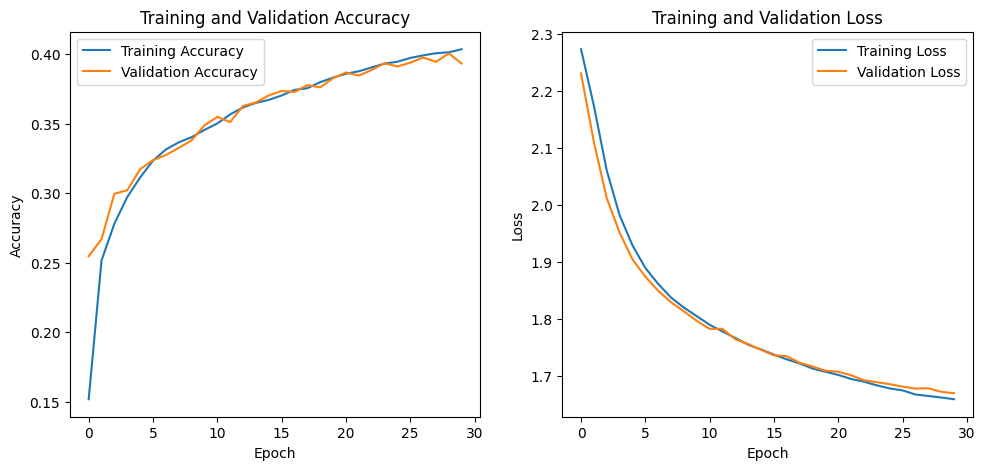

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step


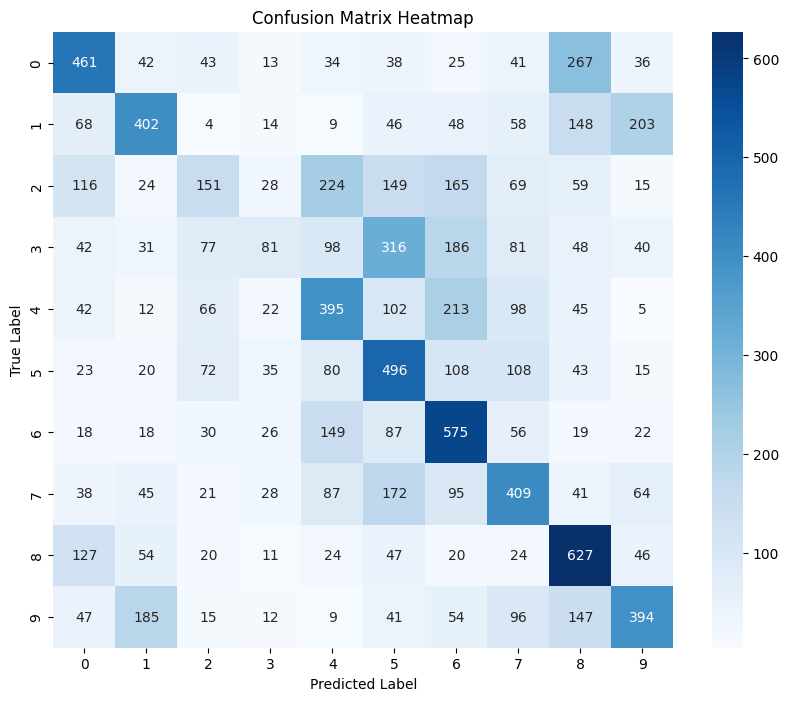

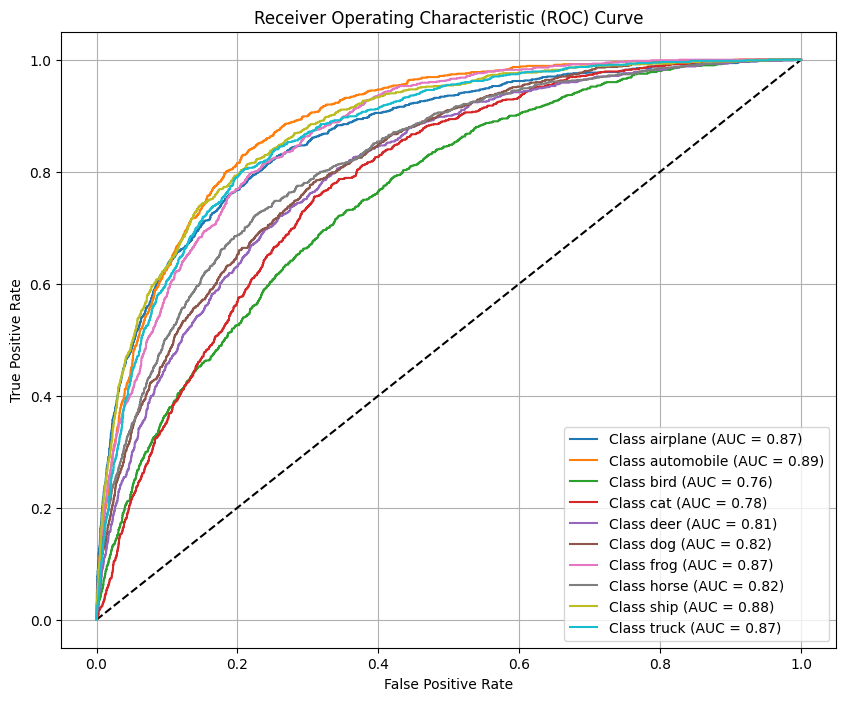

Final Test Accuracy: 0.3991
Final Test Loss: 1.6598


In [ ]:
# Example usage for VGG-16 on CIFAR-10
train_and_evaluate_model(get_vgg_model, 'VGG-16', 'cifar10')

####Recurrent Neural Networks (RNN):


--- Training RNN on cifar10 ---
--- Evaluating different train-test splits ---

Training with 20% test set split:
---------------------------------------------------------------------------
Epoch     Accuracy       Loss           Val_Accuracy   Val_Loss       
---------------------------------------------------------------------------
1         0.2161         2.1771         0.2306         2.1100         
2         0.2689         2.0207         0.2698         2.0107         
3         0.2984         1.9370         0.2891         1.9398         
4         0.3077         1.9064         0.2953         1.9308         
5         0.3189         1.8731         0.3067         1.9136         
6         0.3303         1.8444         0.3123         1.8689         
7         0.3360         1.8266         0.3227         1.8609         
8         0.3408         1.8141         0.3262         1.8466         
9         0.3489         1.7880         0.3352         1.8307         
10        0.3590       

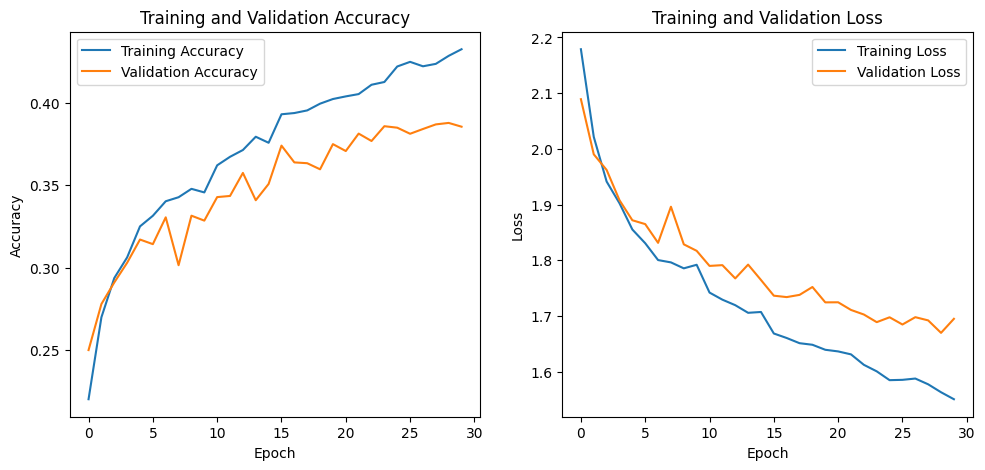

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


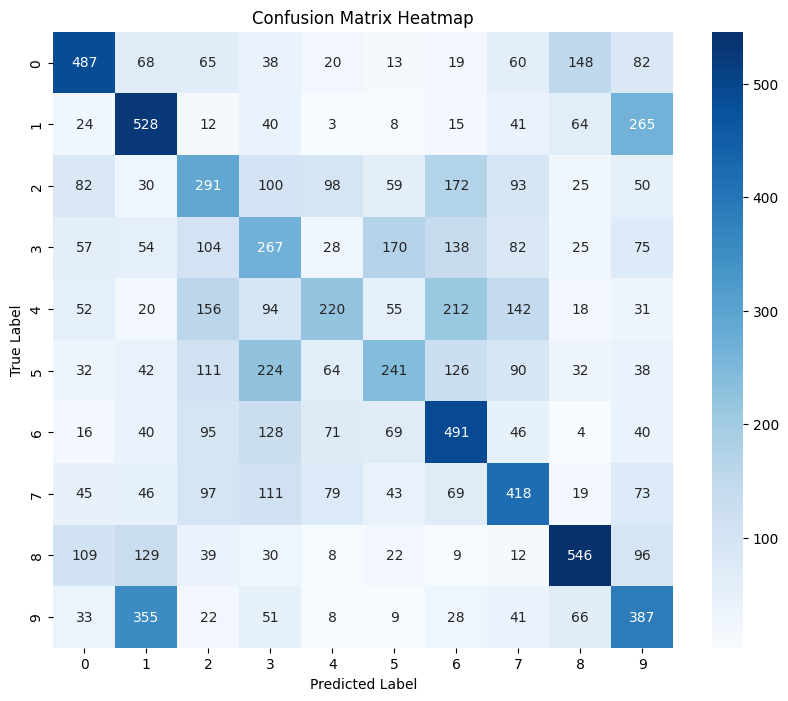

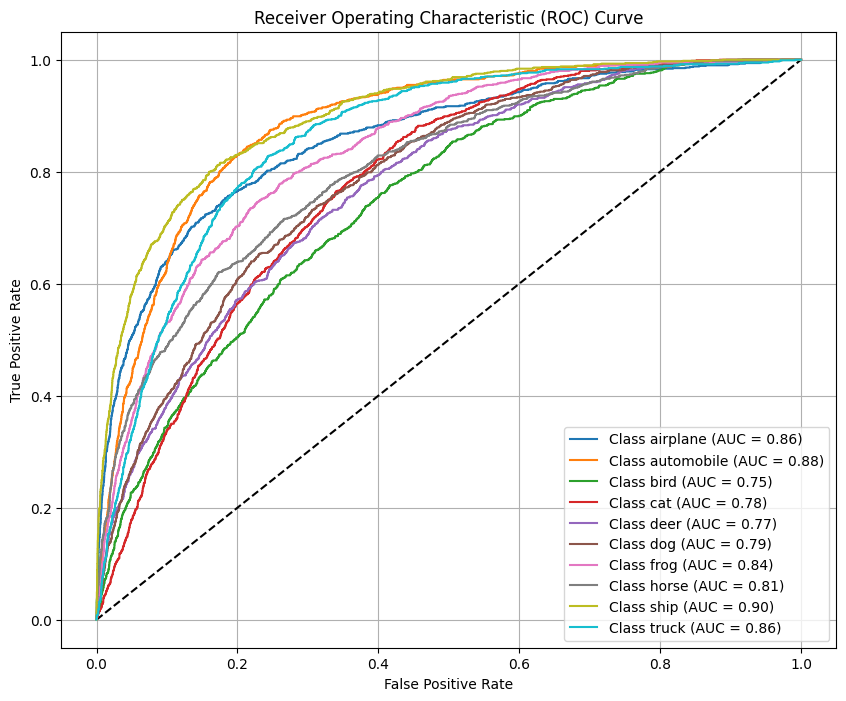

Final Test Accuracy: 0.3876
Final Test Loss: 1.6933


In [ ]:
train_and_evaluate_model(get_rnn_model_cifar, 'RNN', 'cifar10')

####AlexNet:


--- Training AlexNet on cifar10 ---
--- Evaluating different train-test splits ---

Training with 20% test set split:
---------------------------------------------------------------------------
Epoch     Accuracy       Loss           Val_Accuracy   Val_Loss       
---------------------------------------------------------------------------
1         0.0975         2.8081         0.0933         2.3029         
2         0.1009         2.3027         0.0973         2.3031         
3         0.1006         2.3027         0.0933         2.3029         
4         0.0992         2.3027         0.0933         2.3030         
5         0.1004         2.3027         0.0933         2.3028         
6         0.0988         2.3027         0.0933         2.3028         
7         0.1007         2.3027         0.0933         2.3029         
8         0.0999         2.3026         0.0933         2.3028         
9         0.0986         2.3027         0.0933         2.3029         
10        0.1005   

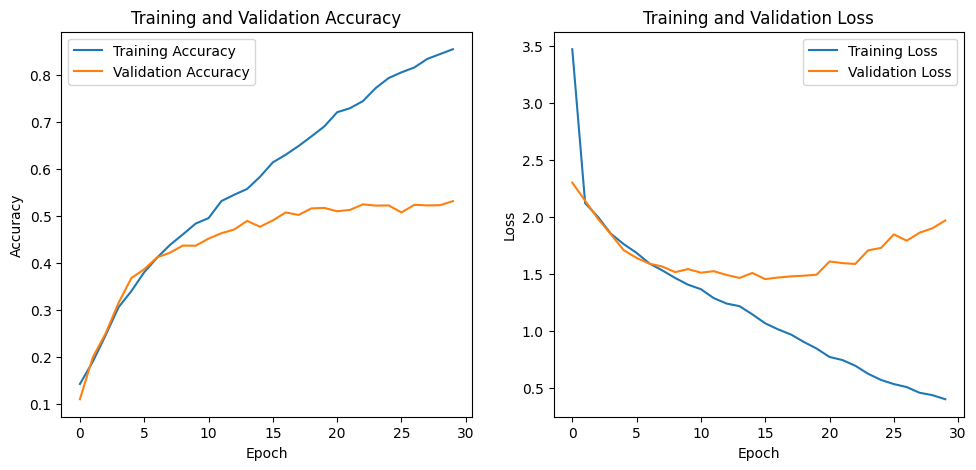

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step


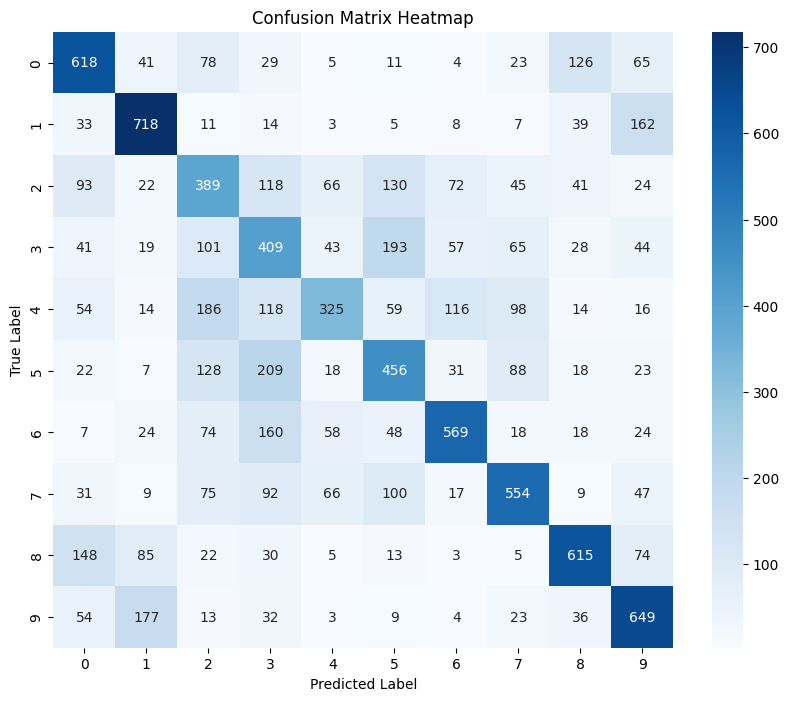

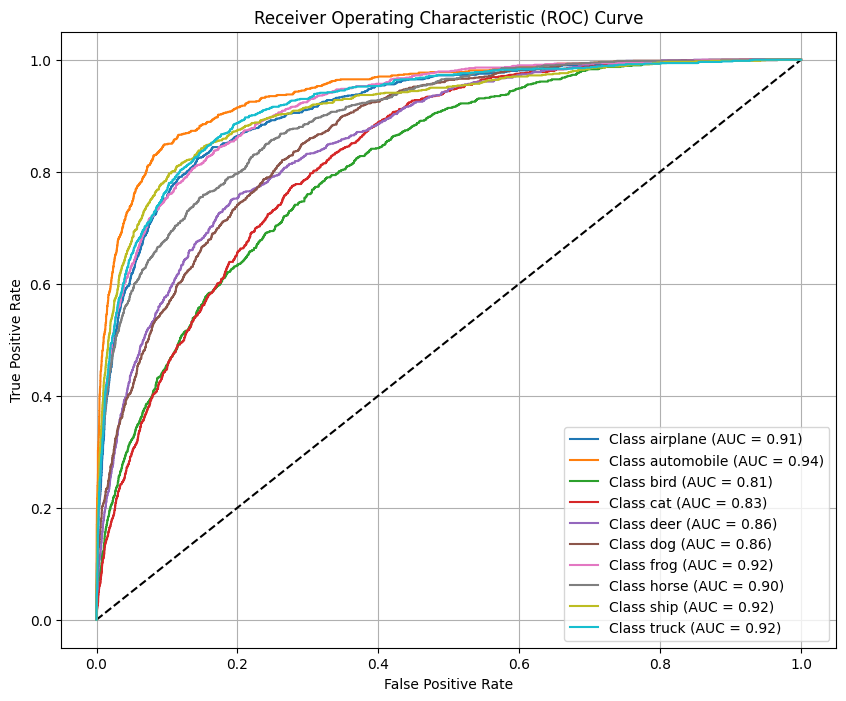

Final Test Accuracy: 0.5302
Final Test Loss: 1.9663


In [9]:
train_and_evaluate_model(get_alexnet_model, 'AlexNet', 'cifar10')

####GoogLeNet:


--- Training GoogLeNet on cifar10 ---
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
--- Evaluating different train-test splits ---

Training with 20% test set split:
--------------------------------------------------
Epoch     Accuracy       Loss           Val_Accuracy   Val_Loss       
--------------------------------------------------
1         0.2232         2.1615         0.1553         2.3113         
2         0.3264         1.8108         0.1030         2.3808         
3         0.3978         1.6330         0.1020         2.5148         
4         0.4562         1.4896         0.1020         2.7192         
5         0.4998         1.3965         0.1220         2.9817         
6         0.5358         1.2902         0.1249         3.2387         
7         0.5686         1.2113         0.1134         3.5035         
8         0.6000         1.1292         0.1275         3.6324         
9         0.6268         1.0552         0.1263         3.7771         
10        0.6

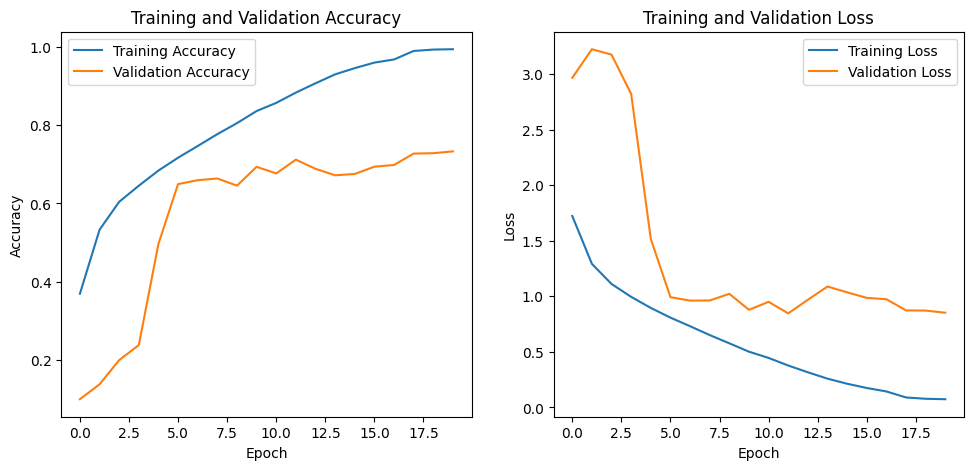

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step


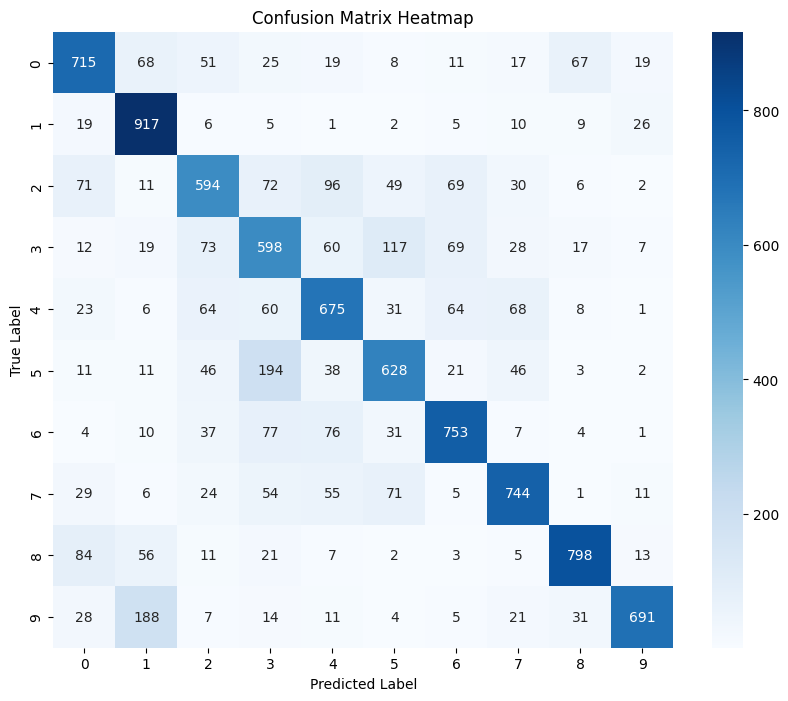

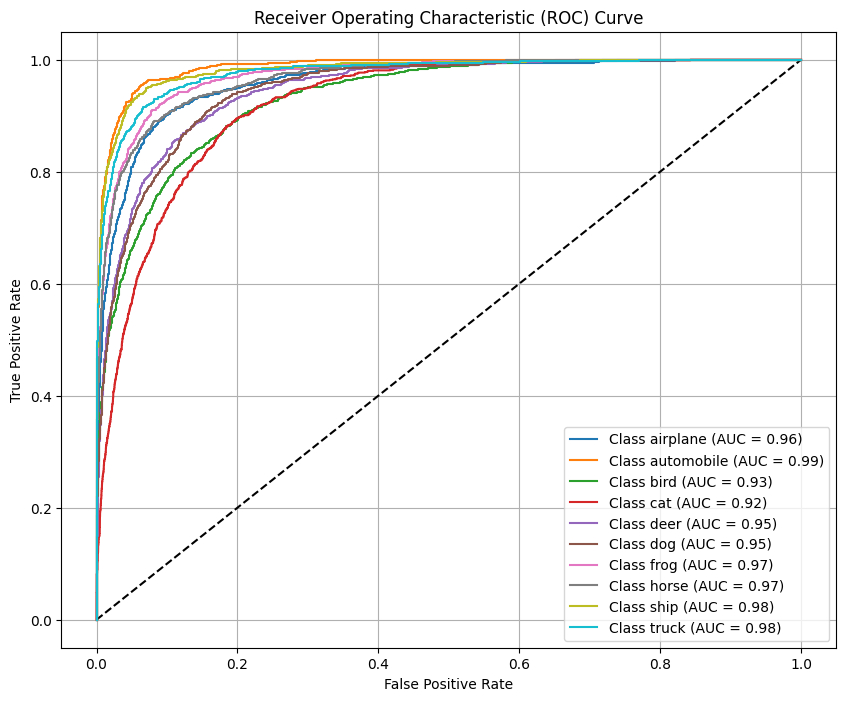

Final Test Accuracy: 0.7113
Final Test Loss: 0.8429


In [ ]:

train_and_evaluate_googlenet_model(get_googlenet_model, 'GoogLeNet', 'cifar10', epochs=20, batch_size=256)

###MNIST

####VGG-16:


--- Training VGG-16 on mnist ---
--- Evaluating different train-test splits ---

Training with 20% test set split:
---------------------------------------------------------------------------
Epoch     Accuracy       Loss           Val_Accuracy   Val_Loss       
---------------------------------------------------------------------------
1         0.1136         2.2994         0.1102         2.2958         
2         0.1486         2.2878         0.1704         2.2781         
3         0.1925         2.2620         0.1957         2.2453         
4         0.2068         2.2240         0.2091         2.2056         
5         0.2198         2.1836         0.2256         2.1674         
6         0.2317         2.1481         0.2492         2.1357         
7         0.2531         2.1185         0.2657         2.1085         
8         0.2668         2.0937         0.2733         2.0853         
9         0.2841         2.0712         0.2953         2.0648         
10        0.2966      

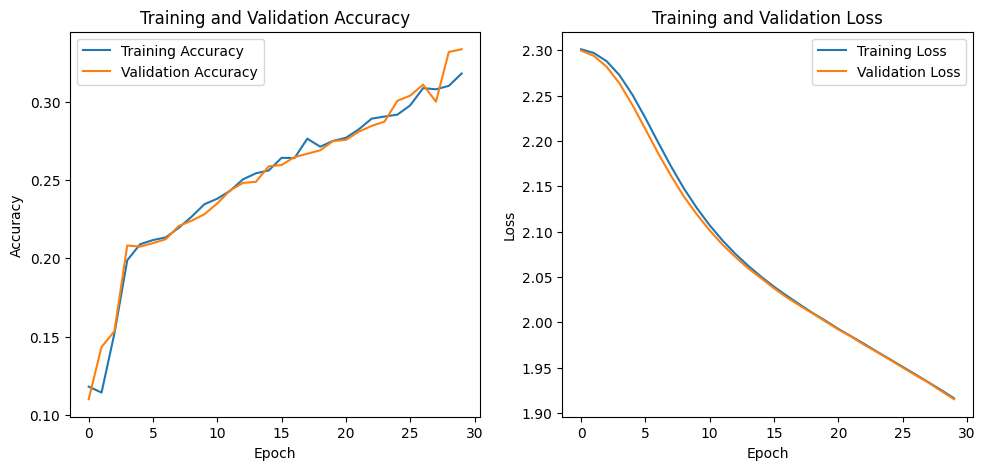

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step


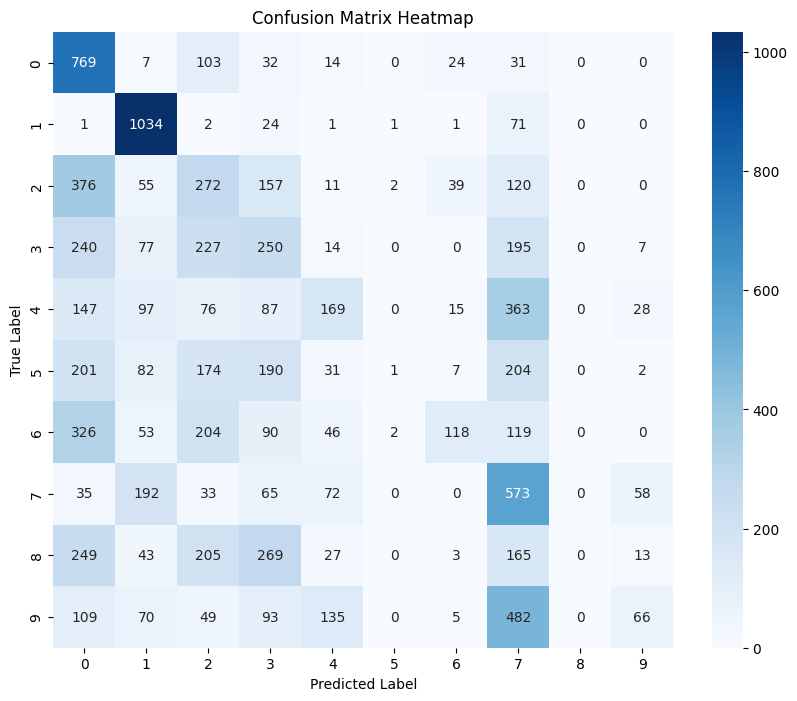

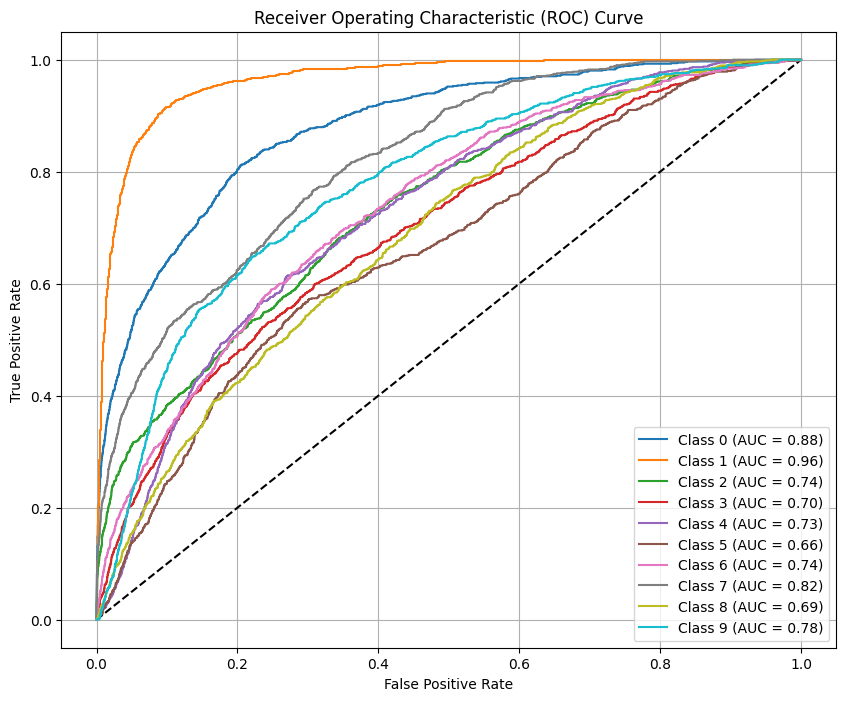

Final Test Accuracy: 0.3252
Final Test Loss: 1.9077


In [ ]:
train_and_evaluate_model(get_vgg_model, 'VGG-16', 'mnist')

####Recurrent Neural Networks (RNN):


--- Training RNN on mnist ---
--- Evaluating different train-test splits ---

Training with 20% test set split:
---------------------------------------------------------------------------
Epoch     Accuracy       Loss           Val_Accuracy   Val_Loss       
---------------------------------------------------------------------------
1         0.8410         0.5272         0.9280         0.2403         
2         0.9420         0.1966         0.9503         0.1680         
3         0.9576         0.1433         0.9609         0.1429         
4         0.9657         0.1145         0.9611         0.1309         
5         0.9693         0.1037         0.9699         0.1007         
6         0.9728         0.0891         0.9698         0.1021         
7         0.9754         0.0813         0.9695         0.1025         
8         0.9786         0.0720         0.9699         0.1030         
9         0.9791         0.0683         0.9753         0.0864         
10        0.9811         

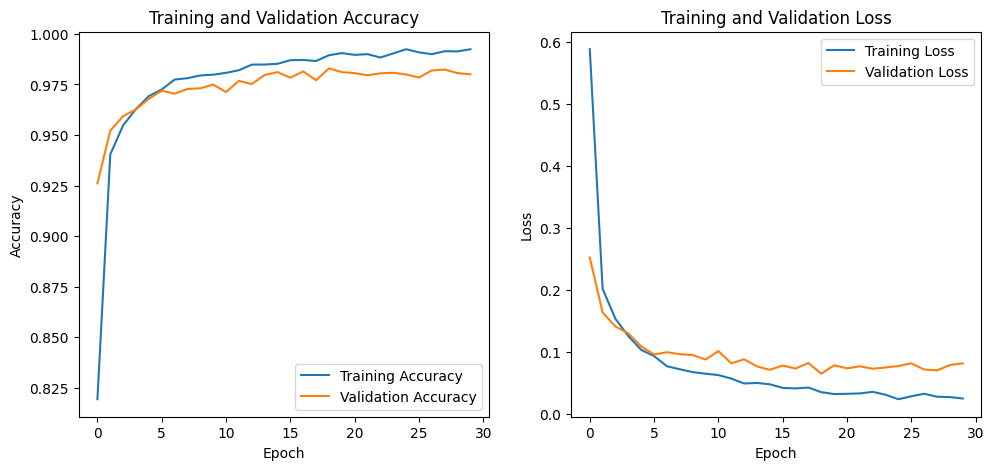

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


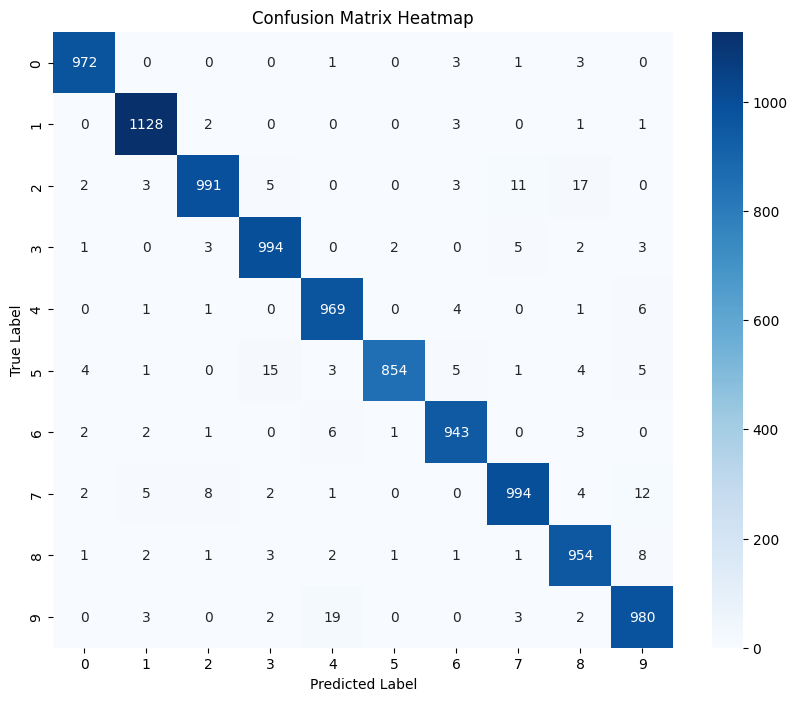

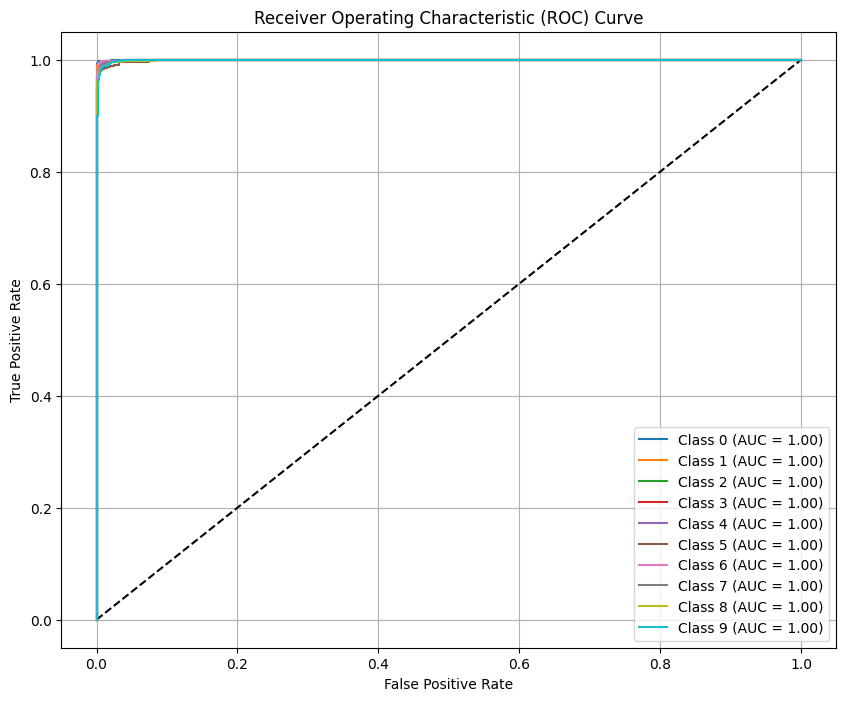

Final Test Accuracy: 0.9779
Final Test Loss: 0.0808


In [ ]:
train_and_evaluate_model(get_rnn_model_mnist, 'RNN', 'mnist')

####AlexNet:


--- Training AlexNet on mnist ---
--- Evaluating different train-test splits ---

Training with 20% test set split:
---------------------------------------------------------------------------
Epoch     Accuracy       Loss           Val_Accuracy   Val_Loss       
---------------------------------------------------------------------------
1         0.3190         2.3760         0.1102         6.6077         
2         0.8892         0.3523         0.1102         5.6098         
3         0.9635         0.1187         0.1102         5.4307         
4         0.9764         0.0767         0.1494         3.1928         
5         0.9803         0.0654         0.4198         1.8596         
6         0.9821         0.0562         0.9137         0.2711         
7         0.9845         0.0478         0.9722         0.0960         
8         0.9860         0.0427         0.9823         0.0603         
9         0.9879         0.0383         0.9848         0.0527         
10        0.9868     

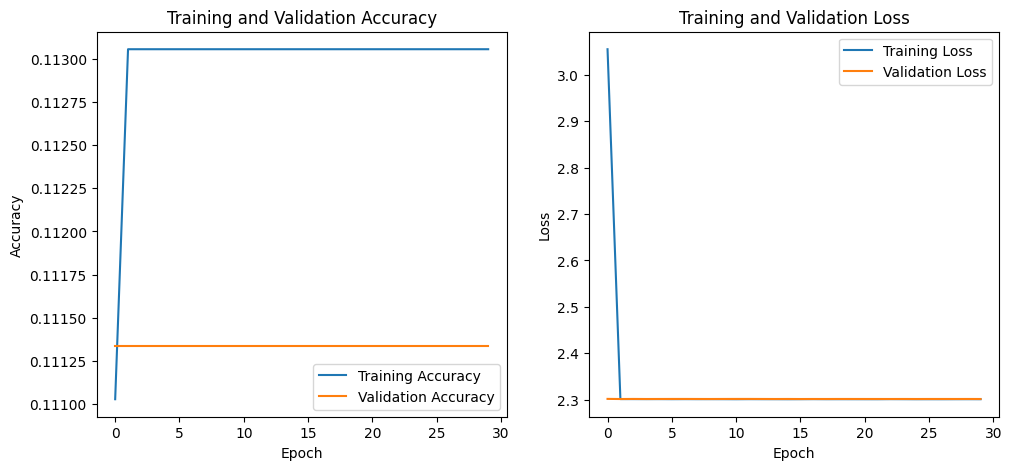

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step


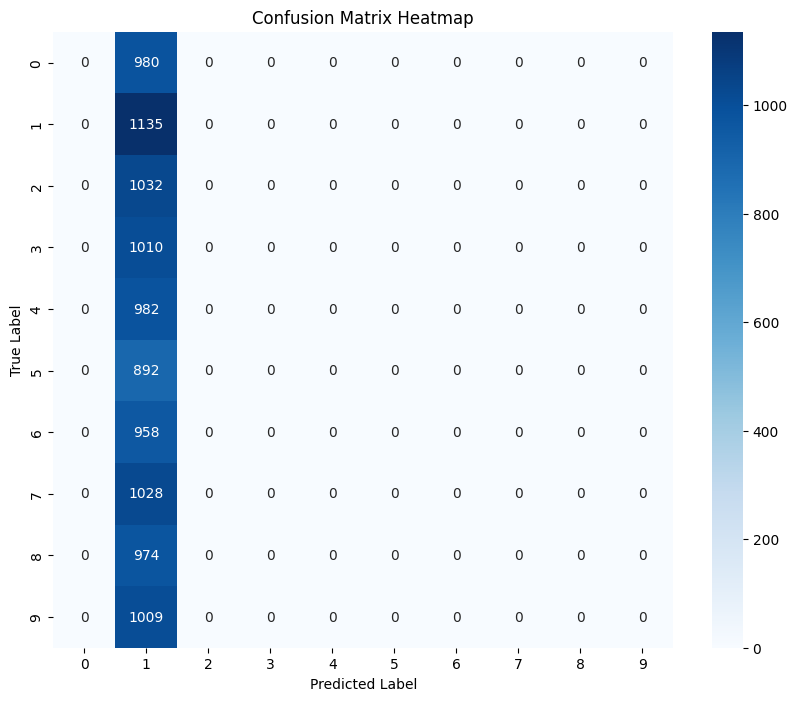

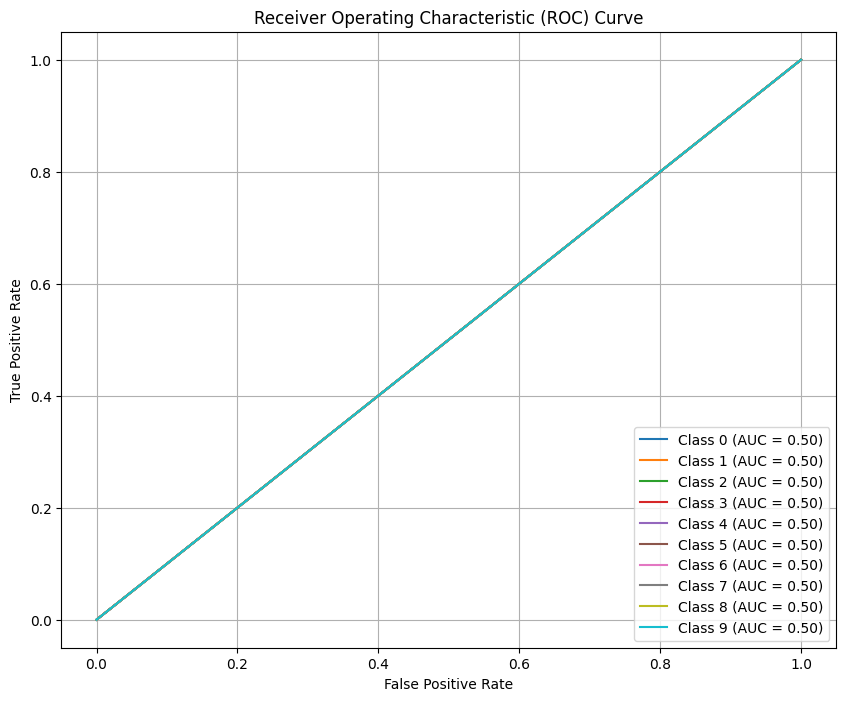

Final Test Accuracy: 0.1135
Final Test Loss: 2.3009


In [4]:
train_and_evaluate_model(get_alexnet_model, 'AlexNet', 'mnist')

####GoogLeNet:


--- Training GoogLeNet on mnist ---
--- Evaluating different train-test splits ---

Training with 20% test set split:
--------------------------------------------------
Epoch     Accuracy       Loss           Val_Accuracy   Val_Loss       
--------------------------------------------------
1         0.3722         1.8719         0.1102         2.3219         
2         0.7166         1.1035         0.1102         2.5192         
3         0.8844         0.6315         0.1102         2.9775         
4         0.9336         0.3823         0.1102         3.6303         
5         0.9606         0.2560         0.1102         4.3767         
6         0.9686         0.1956         0.1102         5.0939         
7         0.9776         0.1523         0.1102         5.8013         
8         0.9818         0.1235         0.1102         6.3680         
9         0.9856         0.1011         0.1102         6.8415         
10        0.9898         0.0812         0.1102         7.2551        

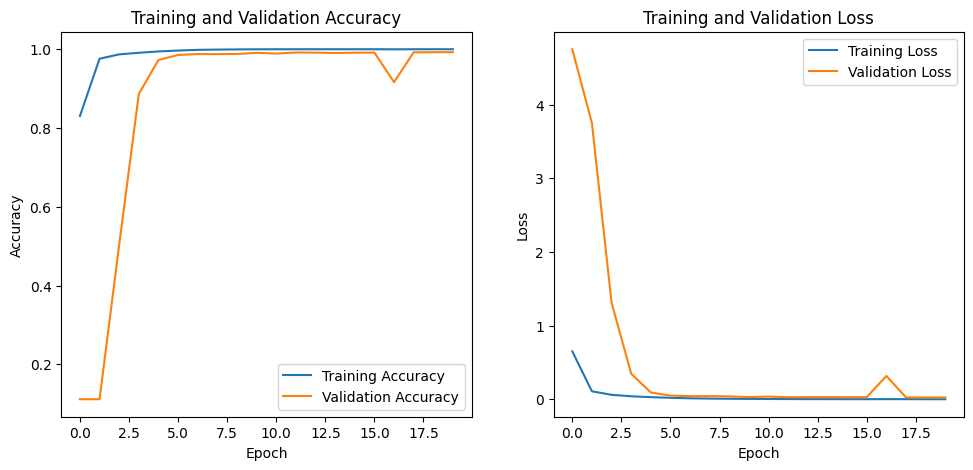

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step


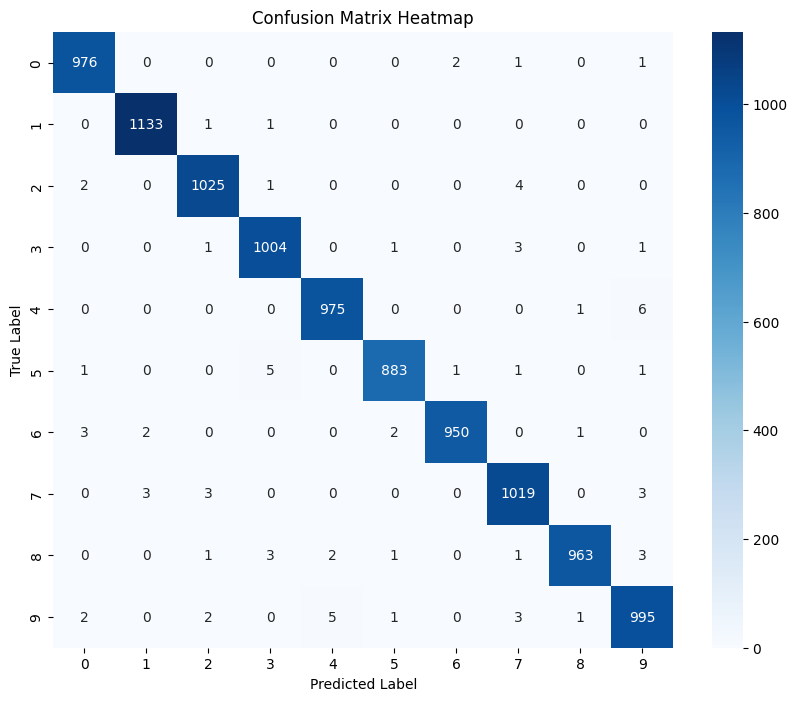

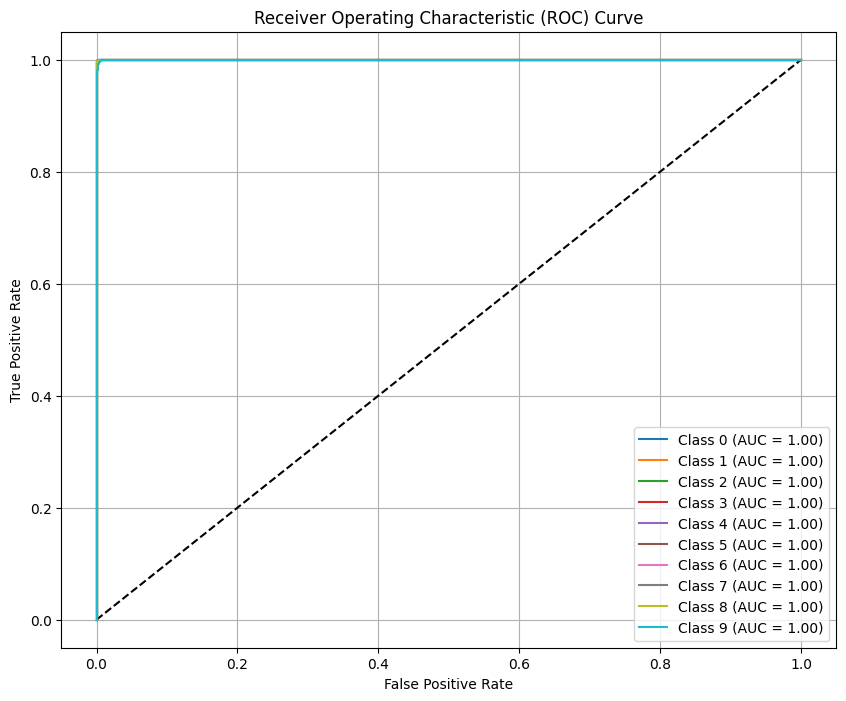

Final Test Accuracy: 0.9923
Final Test Loss: 0.0205


In [ ]:
train_and_evaluate_googlenet_model(get_googlenet_model, 'GoogLeNet', 'mnist', epochs=20, batch_size=256)

####Model Performance on CIFAR-10 and MNIST Table

| **Model**   | **Dataset** | **Best Split Ratio** | **Accuracy**        |
|-------------|-------------|-----------------------|---------------------|
| VGG-16      | CIFAR-10    | 20%                  | 0.3552 (35.52%)     |
| RNN         | CIFAR-10    | 20%                  | 0.3443 (34.43%)     |
| AlexNet     | CIFAR-10    | 60%                  | 0.6789 (67.89%)     |
| GoogLeNet   | CIFAR-10    | 40%                  | 0.1660 (16.60%)     |
| VGG-16      | MNIST       | 20%                  | 0.3104 (31.04%)     |
| RNN         | MNIST       | 20%                  | 0.9749 (97.49%)     |
| AlexNet     | MNIST       | 40%                  | 0.9837 (98.37%)     |
| GoogLeNet   | MNIST       | 40%                  | 0.1113 (11.13%)     |


####Discussion


Dataset Characteristics

CIFAR-10:

Contains 60,000 images (32×32 pixels, 10 classes).

Images are colored and more complex, making classification harder.

Small resolution and inter-class similarity (e.g., cats vs dogs, trucks vs cars) increase difficulty.

MNIST:

Contains 70,000 images (28×28 pixels, 10 classes).

Images are grayscale and simple handwritten digits, easier to distinguish.

Less noise and lower complexity compared to CIFAR-10.

Conclusion: Performance is generally higher on MNIST than CIFAR-10 due to dataset simplicity.

Model-wise Observations

VGG-16 on CIFAR-10 (Accuracy: 35.52%)

VGG-16 is deep and requires more data + computation.

CIFAR-10’s small image size makes it hard for such a heavy model to learn effectively.

Underfitting may occur without enough epochs or proper tuning.

RNN on CIFAR-10 (Accuracy: 34.43%)

RNNs are not suitable for spatial image data.

Poor accuracy shows RNNs fail to capture pixel spatial relations.

AlexNet on CIFAR-10 (Accuracy: 67.89%)

Performs much better because it is designed for image classification.

Simpler architecture compared to VGG, fits CIFAR-10 well.

GoogLeNet on CIFAR-10 (Accuracy: 16.60%)

Very low accuracy due to training difficulty and need for large datasets.

May suffer from vanishing gradients or improper hyperparameter tuning.

VGG-16 on MNIST (Accuracy: 31.04%)

Surprisingly poor result, likely due to overfitting or mismatch with MNIST’s simple structure.

RNN on MNIST (Accuracy: 97.49%)

Very high accuracy since sequential pattern extraction works well for digit strokes.

AlexNet on MNIST (Accuracy: 98.37%)

Best performer. CNN structure aligns well with MNIST image features.

GoogLeNet on MNIST (Accuracy: 11.13%)

Extremely low accuracy, suggesting improper implementation, too high complexity, or bad training settings.

Reasons for High and Low Accuracies

High Accuracies:

Achieved on MNIST due to dataset simplicity.

CNN-based models (AlexNet, RNN to some extent) align well with image features.

Low Accuracies:

CIFAR-10 is more challenging → models need deeper training, more epochs, and data augmentation.

Very deep models (GoogLeNet, VGG-16) may underperform if not trained long enough.

RNN not suitable for images, hence poor results.

Possible Improvements

Data Augmentation: Apply rotations, flips, noise, cropping to improve generalization (especially for CIFAR-10).

Hyperparameter Tuning: Optimize learning rate, batch size, and epochs for stable training.

Transfer Learning: Use pretrained models on ImageNet and fine-tune for CIFAR-10/MNIST.

Model Selection:

Use CNN-based models for image datasets.

Avoid RNNs unless working with sequential data (text, speech, etc.).

Regularization Techniques: Dropout, batch normalization, and early stopping to avoid overfitting.

Increase Epochs: Deeper networks need longer training to reach full potential.